In [ ]:
import copy
import csv
import os
import pathlib
import hashlib
import time
import json
from concurrent.futures import ThreadPoolExecutor
import librosa
import matplotlib.pyplot as plt
import numpy
import pandas
import sklearn
import torch
import seaborn as sns
import marimo as mo
import warnings
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from torch import nn
from torch.utils.data import DataLoader, Dataset

In [ ]:
LABEL_COL = "effect_applied"

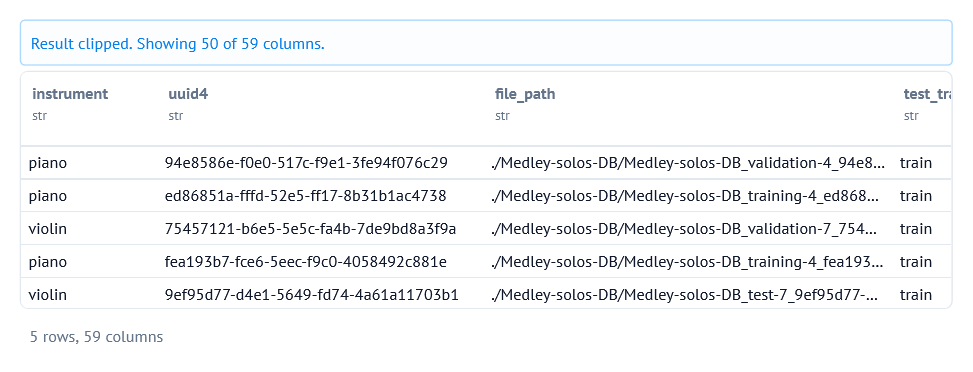

In [ ]:
# Reuse in-memory artifacts from the generation cells when available.
# Fall back to the exported CSVs if this section is run on its own.
FEATURE_DF_PATH = pathlib.Path("feature_df.csv")
AUDIO_SPLIT_CANDIDATES = (
    pathlib.Path("new_df_split.csv"),
    pathlib.Path("train_test_val_mapping.csv"),
)

def load_notebook_artifact(csv_path):
    if not csv_path.exists():
        raise FileNotFoundError(
            f"Missing artifact: {csv_path}. Run data_generation.ipynb through the export cells first."
        )

    dataframe = pandas.read_csv(csv_path)
    unnamed_cols = [c for c in dataframe.columns if str(c).startswith("Unnamed:")]
    if unnamed_cols:
        dataframe = dataframe.drop(columns=unnamed_cols)
    return dataframe

if "feature_df" in globals():
    feature_df = feature_df.copy()
else:
    feature_df = load_notebook_artifact(FEATURE_DF_PATH)

if "new_df_split" in globals():
    new_df_split = new_df_split.copy()
else:
    audio_split_path = next((path for path in AUDIO_SPLIT_CANDIDATES if path.exists()), None)
    if audio_split_path is None:
        raise FileNotFoundError(
            "Missing audio split artifact. Run data_generation.ipynb so it exports new_df_split.csv or train_test_val_mapping.csv."
        )
    new_df_split = load_notebook_artifact(audio_split_path)

feature_df.head()

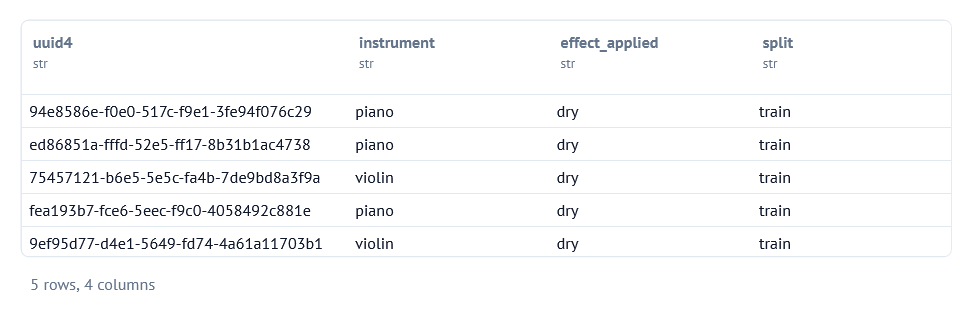

In [ ]:
new_df_split[["uuid4", "instrument", "effect_applied", "split"]].head()

In [ ]:
# Prefer the generation-time split and keep only numeric feature columns.
split_col = "split" if "split" in feature_df.columns else "test_train_val"

excluded_cols = {
    "instrument",
    "uuid4",
    "file_path",
    "new_file_path",
    "wet_dry",
    "parameter",
    "parameter_value",
    "effect_applied",
    "effect",
    "label",
    "split",
    "test_train_val",
}

# if "effect" not in feature_df.columns:
#     feature_df["effect"] = feature_df["new_file_path"].astype(str).str.lstrip("./").str.split("/").str[0]

feature_df["effect"] = feature_df[LABEL_COL]

if feature_df["effect"].isna().any():
    raise ValueError("Missing values in effect_applied — labels are broken.")

feature_cols = [
    c for c in feature_df.columns
    if c not in excluded_cols and pandas.api.types.is_numeric_dtype(feature_df[c])
]

feature_cols

In [ ]:
# Encode labels
label_encoder = sklearn.preprocessing.LabelEncoder()

print("Unique labels:", feature_df["effect"].unique())
feature_df["label"] = label_encoder.fit_transform(feature_df["effect"])

# Split
train_df = feature_df[feature_df[split_col] == "train"].copy()
val_df = feature_df[feature_df[split_col] == "val"].copy()
test_df = feature_df[feature_df[split_col] == "test"].copy()

Unique labels: <StringArray>
['dry', 'reverb', 'delay', 'distortion', 'chorus']
Length: 5, dtype: str


In [ ]:
# Scale features using train only
scaler = sklearn.preprocessing.StandardScaler()
X_train = scaler.fit_transform(train_df[feature_cols])
X_val = scaler.transform(val_df[feature_cols])
X_test = scaler.transform(test_df[feature_cols])

y_train = train_df["label"].to_numpy()
y_val = val_df["label"].to_numpy()
y_test = test_df["label"].to_numpy()

In [ ]:
# Keep the tabular models in one place so swapping is easy.
MODEL_BUILDERS = {
    "logistic_regression": lambda **kwargs: LogisticRegression(
        **{"max_iter": 2000, "random_state": 42, **kwargs}
    ),
    "mlp": lambda **kwargs: MLPClassifier(
        **{
            "hidden_layer_sizes": (256, 128),
            "activation": "relu",
            "solver": "adam",
            "alpha": 1e-4,
            "batch_size": 64,
            "learning_rate_init": 1e-3,
            "max_iter": 400,
            "early_stopping": True,
            "n_iter_no_change": 20,
            "random_state": 42,
            **kwargs,
        }
    ),
    "random_forest": lambda **kwargs: RandomForestClassifier(
        **{"n_estimators": 200, "random_state": 42, "n_jobs": -1, **kwargs}
    ),
    "svm": lambda **kwargs: SVC(
        **{"kernel": "rbf", "C": 1.0, "gamma": "scale", "random_state": 42, **kwargs}
    ),
}

MODEL_ALIASES = {
    "logistic": "logistic_regression",
    "logreg": "logistic_regression",
    "nn": "mlp",
    "rf": "random_forest",
    "randomforest": "random_forest",
    "svc": "svm",
}


def build_model(model_name, **model_kwargs):
    resolved_name = MODEL_ALIASES.get(model_name.lower(), model_name.lower())

    if resolved_name not in MODEL_BUILDERS:
        available_models = ", ".join(sorted(MODEL_BUILDERS))
        raise ValueError(f"Unknown model '{model_name}'. Available models: {available_models}")

    return resolved_name, MODEL_BUILDERS[resolved_name](**model_kwargs)


def evaluate_split(model, X, y, labels):
    y_pred = model.predict(X)

    return {
        "accuracy": accuracy_score(y, y_pred),
        "macro_f1": f1_score(y, y_pred, average="macro", zero_division=0),
        "confusion_matrix": confusion_matrix(y, y_pred, labels=labels),
        "y_true": numpy.array(y),
        "y_pred": numpy.array(y_pred),
    }


def train_and_evaluate(
    model_name,
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    label_encoder=None,
    **model_kwargs,
):
    resolved_name, model = build_model(model_name, **model_kwargs)

    model.fit(X_train, y_train)

    if label_encoder is not None:
        class_names = list(label_encoder.classes_)
        labels = numpy.arange(len(class_names))
    else:
        labels = numpy.unique(numpy.concatenate([y_train, y_val, y_test]))
        class_names = [str(label) for label in labels]

    metrics = {
        "train": evaluate_split(model, X_train, y_train, labels),
        "val": evaluate_split(model, X_val, y_val, labels),
        "test": evaluate_split(model, X_test, y_test, labels),
    }

    confusion_matrices = {
        split_name: pandas.DataFrame(
            split_metrics["confusion_matrix"],
            index=class_names,
            columns=class_names,
        )
        for split_name, split_metrics in metrics.items()
    }

    history_df = pandas.DataFrame([
        {
            "model_name": resolved_name,
            "train_accuracy": metrics["train"]["accuracy"],
            "train_macro_f1": metrics["train"]["macro_f1"],
            "val_accuracy": metrics["val"]["accuracy"],
            "val_macro_f1": metrics["val"]["macro_f1"],
            "test_accuracy": metrics["test"]["accuracy"],
            "test_macro_f1": metrics["test"]["macro_f1"],
        }
    ])

    print(f"Model: {resolved_name}")
    print("\nFinal Metrics")
    print(f"Train accuracy:  {metrics['train']['accuracy']:.4f}")
    print(f"Train macro F1:  {metrics['train']['macro_f1']:.4f}")
    print(f"Val accuracy:    {metrics['val']['accuracy']:.4f}")
    print(f"Val macro F1:    {metrics['val']['macro_f1']:.4f}")
    print(f"Test accuracy:   {metrics['test']['accuracy']:.4f}")
    print(f"Test macro F1:   {metrics['test']['macro_f1']:.4f}")

    return {
        "model_name": resolved_name,
        "model": model,
        "metrics": metrics,
        "confusion_matrices": confusion_matrices,
        "class_names": class_names,
        "history_df": history_df,
    }

In [ ]:
print(new_df_split["effect_applied"].isna().sum())
print(new_df_split["effect_applied"].unique())

0
<StringArray>
['dry', 'reverb', 'delay', 'distortion', 'chorus']
Length: 5, dtype: str


In [ ]:
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.utils.parallel")

# 1. Define the models and their specific hyperparameters
models_to_run = {
    "logistic_regression": {"max_iter": 2000},
    "mlp": {
        "hidden_layer_sizes": (64, 32),
        "alpha": 1e-4,
        "max_iter": 500,
        "early_stopping": True,
    },
    "random_forest": {
        "n_estimators": 200,
        "max_depth": 12,
        "min_samples_leaf": 5,
    },
    "svm": {
        "kernel": "rbf",
        "C": 1.0,
        "gamma": "scale",
    }
}

# Ensure the output directory exists
os.makedirs('./images', exist_ok=True)

# Define visual constants
CELL_TEXT_SIZE = 14
LABEL_SIZE = 16
TICK_SIZE = 14
TITLE_SIZE = 22

# 2. Iterate through each model
for model_name, model_kwargs in models_to_run.items():
    print(f"\n" + "="*40)
    print(f"RUNNING: {model_name.upper()}")
    print("="*40)

    # Train and Evaluate
    run = train_and_evaluate(
        model_name=model_name,
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        X_test=X_test,
        y_test=y_test,
        label_encoder=label_encoder,
        **model_kwargs,
    )

    # --- NEW: Print Detailed Accuracy Summary ---
    m = run["metrics"]
    print(f"\n--- {model_name.upper()} RESULTS ---")
    print(f"Train Accuracy: {m['train']['accuracy']:.4f} | Macro F1: {m['train']['macro_f1']:.4f}")
    print(f"Val Accuracy:   {m['val']['accuracy']:.4f} | Macro F1: {m['val']['macro_f1']:.4f}")
    print(f"Test Accuracy:  {m['test']['accuracy']:.4f} | Macro F1: {m['test']['macro_f1']:.4f}")
    print("-" * 30)

    # 3. Data Preparation for Plotting
    classes = run["class_names"]
    y_true_test = run["metrics"]["test"]["y_true"]
    y_pred_test = run["metrics"]["test"]["y_pred"]

    # Calculate Raw Confusion Matrix
    cm = confusion_matrix(y_true_test, y_pred_test)

    # Calculate Percentages
    cm_sum = numpy.sum(cm, axis=1, keepdims=True)
    cm_perc = numpy.divide(cm.astype(float), cm_sum, out=numpy.zeros_like(cm, dtype=float), where=cm_sum!=0)

    # Create labels
    annot_labels = numpy.array([
        [f"{p:.1%}\n({int(c)})" for p, c in zip(row_p, row_c)] 
        for row_p, row_c in zip(cm_perc, cm)
    ])

    # 4. Plotting
    fig, ax = plt.subplots(figsize=(12, 8))
    sns.set_theme(style="white")

    ax = sns.heatmap(cm_perc, 
                     annot=annot_labels, 
                     fmt="",            
                     cmap='Blues', 
                     xticklabels=classes, 
                     yticklabels=classes,
                     square=True, 
                     linewidths=.5, 
                     cbar_kws={"shrink": .8},
                     annot_kws={"size": CELL_TEXT_SIZE, "weight": "bold"}, 
                     ax=ax)

    title = f"{model_name.upper()} - Test Confusion Matrix"

    ax.set_title(title, pad=30, fontsize=TITLE_SIZE, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=LABEL_SIZE, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=LABEL_SIZE, fontweight='bold')
    ax.tick_params(axis='both', which='major', labelsize=TICK_SIZE)

    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()

    # 5. Save and Close
    file_name = f"./images/{model_name}_confustion_matrix.png"
    plt.savefig(file_name, bbox_inches='tight', dpi=300)
    plt.close()

    print(f"Successfully saved confusion matrix to: {file_name}")


RUNNING: LOGISTIC_REGRESSION
Model: logistic_regression

Final Metrics
Train accuracy:  0.5129
Train macro F1:  0.5039
Val accuracy:    0.4752
Val macro F1:    0.4700
Test accuracy:   0.5038
Test macro F1:   0.4892

--- LOGISTIC_REGRESSION RESULTS ---
Train Accuracy: 0.5129 | Macro F1: 0.5039
Val Accuracy:   0.4752 | Macro F1: 0.4700
Test Accuracy:  0.5038 | Macro F1: 0.4892
------------------------------
Successfully saved confusion matrix to: ./images/logistic_regression_confustion_matrix.png

RUNNING: MLP
Model: mlp

Final Metrics
Train accuracy:  0.7308
Train macro F1:  0.7260
Val accuracy:    0.5638
Val macro F1:    0.5535
Test accuracy:   0.5867
Test macro F1:   0.5728

--- MLP RESULTS ---
Train Accuracy: 0.7308 | Macro F1: 0.7260
Val Accuracy:   0.5638 | Macro F1: 0.5535
Test Accuracy:  0.5867 | Macro F1: 0.5728
------------------------------
Successfully saved confusion matrix to: ./images/mlp_confustion_matrix.png

RUNNING: RANDOM_FOREST
Model: random_forest

Final Metrics
Tr

In [ ]:
mel_cnn_device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
print("mel_cnn_device =", mel_cnn_device)


# def infer_audio_label(row, audio_col="new_file_path", label_source_col="effect_applied"):
#     if label_source_col in row.index and pandas.notna(row[label_source_col]):
#         return str(row[label_source_col])
#     return pathlib.Path(str(row[audio_col])).parts[0]

def infer_audio_label(row, audio_col="new_file_path", label_source_col=LABEL_COL):
    if label_source_col not in row.index:
        raise ValueError("effect_applied column missing")

    if pandas.isna(row[label_source_col]):
        raise ValueError(f"Missing label for {row[audio_col]}")

    return str(row[label_source_col])


def normalize_aux_feature_sets(aux_feature_sets):
    if aux_feature_sets is None:
        return ()
    if isinstance(aux_feature_sets, str):
        return (aux_feature_sets,)
    return tuple(aux_feature_sets)


def summarize_feature(values, feature_name, stats=("mean", "std")):
    values = numpy.asarray(values).ravel()
    stat_functions = {
        "mean": numpy.mean,
        "std": numpy.std,
    }
    feature_summary = {}
    for stat_name in stats:
        feature_summary[f"{feature_name}_{stat_name}"] = float(stat_functions[stat_name](values))
    return feature_summary


PRECOMPUTED_AUX_FEATURE_SPECS = {
    "rms_stats": (
        ("rms_mean", "rms_energy_mean"),
        ("rms_std", "rms_energy_std"),
    ),
    "spectral_flatness": (
        ("spectral_flatness_mean", "spectral_flatness_mean"),
        ("spectral_flatness_std", "spectral_flatness_std"),
    ),
    "spectral_rolloff": (
        ("spectral_rolloff_mean", "spectral_rolloff_mean"),
        ("spectral_rolloff_std", "spectral_rolloff_std"),
    ),
    "hf_energy_ratio": (
        ("hf_energy_ratio_mean", "hf_energy_ratio_mean"),
        ("hf_energy_ratio_std", "hf_energy_ratio_std"),
    ),
}


def get_precomputed_aux_source_columns(aux_feature_sets):
    columns = []
    for feature_set in normalize_aux_feature_sets(aux_feature_sets):
        columns.extend(source_col for _, source_col in PRECOMPUTED_AUX_FEATURE_SPECS.get(feature_set, ()))
    return tuple(dict.fromkeys(columns))


def read_csv_header(csv_path):
    with open(csv_path, newline="") as handle:
        reader = csv.reader(handle)
        return next(reader)


def attach_precomputed_aux_features(dataframe, aux_feature_sets, feature_csv_path="feature_df.csv"):
    required_columns = get_precomputed_aux_source_columns(aux_feature_sets)
    if not required_columns:
        return dataframe

    if all(column in dataframe.columns for column in required_columns):
        return dataframe

    feature_csv = pathlib.Path(feature_csv_path)
    if not feature_csv.exists():
        return dataframe

    header = read_csv_header(feature_csv)
    available_required_columns = [column for column in required_columns if column in header]
    missing_required_columns = [column for column in required_columns if column not in available_required_columns]
    if missing_required_columns:
        return dataframe

    merge_keys = [column for column in ("uuid4", "new_file_path") if column in dataframe.columns and column in header]
    if not merge_keys:
        return dataframe

    merge_columns = merge_keys + available_required_columns
    feature_frame = pandas.read_csv(feature_csv, usecols=merge_columns).drop_duplicates(subset=merge_keys)
    enriched = dataframe.merge(feature_frame, on=merge_keys, how="left")
    return enriched


def format_elapsed_seconds(seconds):
    total_seconds = int(round(float(seconds)))
    minutes, seconds = divmod(total_seconds, 60)
    hours, minutes = divmod(minutes, 60)
    if hours:
        return f"{hours:d}h {minutes:02d}m {seconds:02d}s"
    if minutes:
        return f"{minutes:d}m {seconds:02d}s"
    return f"{seconds:d}s"


def build_audio_classification_dataframe(
    dataframe,
    audio_col="new_file_path",
    split_col="split",
    label_source_col="effect_applied",
    label_encoder=None,
):
    resolved_split_col = split_col if split_col in dataframe.columns else "test_train_val"

    audio_df = dataframe.copy()
    audio_df["effect"] = audio_df.apply(
        lambda row: infer_audio_label(row, audio_col=audio_col, label_source_col=label_source_col),
        axis=1,
    )

    if label_encoder is None:
        label_encoder = sklearn.preprocessing.LabelEncoder()
        audio_df["label"] = label_encoder.fit_transform(audio_df["effect"])
    else:
        audio_df["label"] = label_encoder.transform(audio_df["effect"])

    split_frames = {
        split_name: audio_df[audio_df[resolved_split_col] == split_name].reset_index(drop=True)
        for split_name in ["train", "val", "test"]
    }

    return {
        "audio_df": audio_df,
        "split_col": resolved_split_col,
        "label_encoder": label_encoder,
        "train_df": split_frames["train"],
        "val_df": split_frames["val"],
        "test_df": split_frames["test"],
    }


def extract_rms_stats_features(y, sr):
    rms = librosa.feature.rms(y=y).ravel()
    return {
        "rms_mean": float(numpy.mean(rms)),
        "rms_std": float(numpy.std(rms)),
    }


def extract_spectral_flatness_features(y, sr, stats=("mean", "std")):
    flatness = librosa.feature.spectral_flatness(y=y)
    return summarize_feature(flatness, "spectral_flatness", stats=stats)


def extract_spectral_rolloff_features(y, sr, stats=("mean", "std")):
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    return summarize_feature(rolloff, "spectral_rolloff", stats=stats)


def extract_hf_energy_ratio_features(y, sr, cutoff_hz=4000.0, stats=("mean", "std")):
    stft = numpy.abs(librosa.stft(y=y, n_fft=1024, hop_length=256)) ** 2
    freqs = librosa.fft_frequencies(sr=sr, n_fft=1024)
    hf_mask = freqs >= cutoff_hz
    total_energy = numpy.sum(stft, axis=0)
    hf_energy = numpy.sum(stft[hf_mask], axis=0)
    ratio = hf_energy / numpy.maximum(total_energy, 1e-8)
    return summarize_feature(ratio, "hf_energy_ratio", stats=stats)


HYBRID_AUX_FEATURE_BUILDERS = {
    "rms_stats": extract_rms_stats_features,
    "spectral_flatness": extract_spectral_flatness_features,
    "spectral_rolloff": extract_spectral_rolloff_features,
    "hf_energy_ratio": extract_hf_energy_ratio_features,
}


def build_scheduler(optimizer, scheduler_name=None, scheduler_kwargs=None, monitor_name=None):
    scheduler_kwargs = {} if scheduler_kwargs is None else dict(scheduler_kwargs)

    if scheduler_name in [None, False, "none"]:
        return None

    if scheduler_name == "reduce_on_plateau":
        if "mode" not in scheduler_kwargs:
            scheduler_kwargs["mode"] = "max" if monitor_name == "val_macro_f1" else "min"
        return torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, **scheduler_kwargs)

    raise ValueError("Unsupported lr_scheduler_name. Available: None, 'reduce_on_plateau'.")


def get_monitor_value(metrics, monitor_name):
    if monitor_name not in metrics:
        available = ", ".join(sorted(metrics))
        raise ValueError(f"Unknown monitor '{monitor_name}'. Available: {available}")
    return metrics[monitor_name]


def is_better_monitor_value(candidate, best_value, monitor_name):
    if best_value is None:
        return True
    if monitor_name == "val_loss":
        return candidate < best_value
    if monitor_name == "val_macro_f1":
        return candidate > best_value
    raise ValueError("Supported monitors: 'val_loss', 'val_macro_f1'.")


def _make_cache_spec(sample_rate, fixed_duration, n_mels, n_fft, hop_length, power, normalize, aux_feature_sets):
    return {
        "sample_rate": sample_rate,
        "fixed_duration": fixed_duration,
        "n_mels": n_mels,
        "n_fft": n_fft,
        "hop_length": hop_length,
        "power": power,
        "normalize": normalize,
        "aux_feature_sets": list(normalize_aux_feature_sets(aux_feature_sets)),
    }


def _make_row_cache_key(row, cache_spec, audio_col="new_file_path"):
    base = {
        "audio_path": str(row[audio_col]),
        "uuid4": str(row["uuid4"]) if "uuid4" in row.index else "",
        "spec": cache_spec,
    }
    payload = json.dumps(base, sort_keys=True)
    return hashlib.sha1(payload.encode("utf-8")).hexdigest()


def precompute_mel_cache(
    dataframe,
    cache_dir="mel_cache_v1",
    audio_col="new_file_path",
    sample_rate=22050,
    fixed_duration=3.0,
    n_mels=128,
    n_fft=1024,
    hop_length=256,
    power=2.0,
    normalize="per_sample",
    aux_feature_sets=("rms_stats", "spectral_flatness"),
):
    cache_dir = pathlib.Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)

    aux_feature_sets = normalize_aux_feature_sets(aux_feature_sets)
    cache_spec = _make_cache_spec(
        sample_rate=sample_rate,
        fixed_duration=fixed_duration,
        n_mels=n_mels,
        n_fft=n_fft,
        hop_length=hop_length,
        power=power,
        normalize=normalize,
        aux_feature_sets=aux_feature_sets,
    )

    num_samples = int(sample_rate * fixed_duration)
    total = len(dataframe)
    start_time = time.time()

    print(f"Precomputing mel cache into: {cache_dir}", flush=True)

    for idx, (_, row) in enumerate(dataframe.iterrows(), start=1):
        cache_key = _make_row_cache_key(row, cache_spec, audio_col=audio_col)
        cache_path = cache_dir / f"{cache_key}.npz"

        if cache_path.exists():
            continue

        y, _ = librosa.load(row[audio_col], sr=sample_rate, mono=True)
        if len(y) < num_samples:
            y = numpy.pad(y, (0, num_samples - len(y)))
        else:
            y = y[:num_samples]

        mel = librosa.feature.melspectrogram(
            y=y,
            sr=sample_rate,
            n_fft=n_fft,
            hop_length=hop_length,
            n_mels=n_mels,
            power=power,
        )
        mel_db = librosa.power_to_db(mel, ref=numpy.max)

        if normalize in [None, False, "none"]:
            pass
        elif normalize == "per_sample":
            mel_mean = numpy.mean(mel_db)
            mel_std = numpy.std(mel_db)
            mel_db = (mel_db - mel_mean) / (mel_std + 1e-8)
        elif normalize == "minmax":
            mel_min = numpy.min(mel_db)
            mel_max = numpy.max(mel_db)
            mel_db = (mel_db - mel_min) / (mel_max - mel_min + 1e-8)
        else:
            raise ValueError("normalize must be one of None, 'per_sample', or 'minmax'.")

        feature_values = {}
        for feature_set in aux_feature_sets:
            feature_values.upandasate(HYBRID_AUX_FEATURE_BUILDERS[feature_set](y=y, sr=sample_rate))

        aux_names = list(feature_values.keys())
        aux_vector = numpy.asarray([feature_values[name] for name in aux_names], dtype=numpy.float32)
        aux_vector = numpy.nan_to_num(aux_vector, nan=0.0, posinf=0.0, neginf=0.0)

        numpy.savez_compressed(
            cache_path,
            mel=mel_db.astype(numpy.float32),
            aux=aux_vector.astype(numpy.float32),
            aux_names=numpy.asarray(aux_names, dtype=object),
        )

        if idx % max(1, total // 10) == 0 or idx == total:
            elapsed = time.time() - start_time
            print(
                f"cache {idx}/{total} | elapsed={format_elapsed_seconds(elapsed)}",
                flush=True,
            )

    print("Mel cache precompute complete.", flush=True)


class MelSpectrogramDataset(Dataset):
    def __init__(
        self,
        dataframe,
        audio_col="new_file_path",
        label_col="label",
        sample_rate=22050,
        fixed_duration=3.0,
        n_mels=128,
        n_fft=1024,
        hop_length=256,
        power=2.0,
        normalize="per_sample",
        aux_feature_sets=("rms_stats", "spectral_flatness"),
        aux_feature_stats=None,
        aux_clip_value=5.0,
        cache_spectrograms=True,
        cache_dir="mel_cache_v1",
        use_disk_cache=True,
    ):
        self.dataframe = dataframe.reset_index(drop=True)
        self.audio_col = audio_col
        self.label_col = label_col
        self.sample_rate = sample_rate
        self.fixed_duration = fixed_duration
        self.n_mels = n_mels
        self.n_fft = n_fft
        self.hop_length = hop_length
        self.power = power
        self.normalize = normalize
        self.aux_feature_sets = normalize_aux_feature_sets(aux_feature_sets)
        self.aux_feature_stats = aux_feature_stats
        self.aux_clip_value = aux_clip_value
        self.cache_spectrograms = cache_spectrograms
        self.use_disk_cache = use_disk_cache
        self.cache_dir = pathlib.Path(cache_dir)
        self.cache_dir.mkdir(parents=True, exist_ok=True)
        self.num_samples = int(sample_rate * fixed_duration)
        self._cache = {} if cache_spectrograms else None
        self.aux_feature_names = None
        self.precomputed_aux_source_columns = get_precomputed_aux_source_columns(self.aux_feature_sets)
        self.cache_spec = _make_cache_spec(
            sample_rate=sample_rate,
            fixed_duration=fixed_duration,
            n_mels=n_mels,
            n_fft=n_fft,
            hop_length=hop_length,
            power=power,
            normalize=normalize,
            aux_feature_sets=self.aux_feature_sets,
        )

    def __len__(self):
        return len(self.dataframe)

    def _load_audio(self, audio_path):
        y, _ = librosa.load(audio_path, sr=self.sample_rate, mono=True)
        if len(y) < self.num_samples:
            y = numpy.pad(y, (0, self.num_samples - len(y)))
        else:
            y = y[:self.num_samples]
        return y

    def _normalize_mel(self, mel_db):
        if self.normalize in [None, False, "none"]:
            return mel_db
        if self.normalize == "per_sample":
            mean = numpy.mean(mel_db)
            std = numpy.std(mel_db)
            return (mel_db - mean) / (std + 1e-8)
        if self.normalize == "minmax":
            min_val = numpy.min(mel_db)
            max_val = numpy.max(mel_db)
            return (mel_db - min_val) / (max_val - min_val + 1e-8)
        raise ValueError("normalize must be one of None, 'per_sample', or 'minmax'.")

    def _sanitize_aux_vector(self, aux_vector):
        aux_vector = numpy.asarray(aux_vector, dtype=numpy.float32)
        return numpy.nan_to_num(aux_vector, nan=0.0, posinf=0.0, neginf=0.0)

    def _get_cache_path(self, row):
        cache_key = _make_row_cache_key(row, self.cache_spec, audio_col=self.audio_col)
        return self.cache_dir / f"{cache_key}.npz"

    def _get_precomputed_aux_features(self, row):
        if row is None:
            return None
        if not self.aux_feature_sets:
            return numpy.zeros(0, dtype=numpy.float32), []
        if not self.precomputed_aux_source_columns:
            return None
        if not all(source_col in row.index and pandas.notna(row[source_col]) for source_col in self.precomputed_aux_source_columns):
            return None

        feature_names = []
        feature_values = []
        for feature_set in self.aux_feature_sets:
            specs = PRECOMPUTED_AUX_FEATURE_SPECS.get(feature_set)
            if not specs:
                return None
            for feature_name, source_col in specs:
                feature_names.append(feature_name)
                feature_values.append(float(row[source_col]))
        aux_vector = self._sanitize_aux_vector(feature_values)
        return aux_vector, feature_names

    def _compute_aux_features(self, y=None, row=None):
        if not self.aux_feature_sets:
            return numpy.zeros(0, dtype=numpy.float32), []

        precomputed = self._get_precomputed_aux_features(row)
        if precomputed is not None:
            return precomputed
        if y is None:
            raise ValueError("Audio waveform is required when precomputed aux features are unavailable.")

        feature_values = {}
        for feature_set in self.aux_feature_sets:
            if feature_set not in HYBRID_AUX_FEATURE_BUILDERS:
                available = ", ".join(sorted(HYBRID_AUX_FEATURE_BUILDERS))
                raise ValueError(f"Unknown aux_feature_set '{feature_set}'. Available: {available}")
            feature_values.upandasate(HYBRID_AUX_FEATURE_BUILDERS[feature_set](y=y, sr=self.sample_rate))

        feature_names = list(feature_values.keys())
        aux_vector = self._sanitize_aux_vector([feature_values[name] for name in feature_names])
        return aux_vector, feature_names

    def _normalize_aux_vector(self, aux_vector):
        if self.aux_feature_stats is not None and len(aux_vector):
            aux_vector = (aux_vector - self.aux_feature_stats["mean"]) / self.aux_feature_stats["std"]
        if self.aux_clip_value is not None and len(aux_vector):
            aux_vector = numpy.clip(aux_vector, -self.aux_clip_value, self.aux_clip_value)
        return aux_vector.astype(numpy.float32)

    def _compute_and_optionally_cache_disk_item(self, row):
        y = self._load_audio(row[self.audio_col])

        mel = librosa.feature.melspectrogram(
            y=y,
            sr=self.sample_rate,
            n_fft=self.n_fft,
            hop_length=self.hop_length,
            n_mels=self.n_mels,
            power=self.power,
        )
        mel_db = librosa.power_to_db(mel, ref=numpy.max)
        mel_db = self._normalize_mel(mel_db).astype(numpy.float32)

        aux_vector, feature_names = self._compute_aux_features(y=y, row=row)
        aux_vector = self._normalize_aux_vector(aux_vector)

        if self.use_disk_cache:
            cache_path = self._get_cache_path(row)
            if not cache_path.exists():
                numpy.savez_compressed(
                    cache_path,
                    mel=mel_db.astype(numpy.float32),
                    aux=aux_vector.astype(numpy.float32),
                    aux_names=numpy.asarray(feature_names, dtype=object),
                )

        return mel_db, aux_vector, feature_names

    def _compute_item(self, index):
        row = self.dataframe.iloc[index]

        if self.use_disk_cache:
            cache_path = self._get_cache_path(row)
            if cache_path.exists():
                cached = numpy.load(cache_path, allow_pickle=True)
                mel_db = cached["mel"].astype(numpy.float32)
                aux_vector = cached["aux"].astype(numpy.float32)
                feature_names = list(cached["aux_names"])
            else:
                mel_db, aux_vector, feature_names = self._compute_and_optionally_cache_disk_item(row)
        else:
            mel_db, aux_vector, feature_names = self._compute_and_optionally_cache_disk_item(row)

        mel_tensor = torch.from_numpy(mel_db).unsqueeze(0)
        aux_tensor = torch.from_numpy(aux_vector)

        if self.aux_feature_names is None:
            self.aux_feature_names = feature_names

        instr_id = row['instrument']

        label_tensor = torch.tensor(int(row[self.label_col]), dtype=torch.long)
        return mel_tensor, aux_tensor, label_tensor, instr_id

    def __getitem__(self, index):
        if self._cache is not None and index in self._cache:
            return self._cache[index]

        item = self._compute_item(index)
        if self._cache is not None:
            self._cache[index] = item
        return item


class MelSpectrogramEncoder(nn.Module):
    def __init__(self, dropout=0.3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((2, 2)),
        )
        self.projection = nn.Sequential(
            nn.Flatten(),
            nn.LazyLinear(48),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        x = self.features(x)
        return self.projection(x)


class MelSpectrogramCNN(nn.Module):
    def __init__(self, num_classes, dropout=0.3):
        super().__init__()
        self.encoder = MelSpectrogramEncoder(dropout=dropout)
        self.classifier = nn.Sequential(
            nn.Linear(48, 48),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(48, num_classes),
        )

    def encode(self, x):
        return self.encoder(x)

    def forward(self, x, aux_features=None):
        embedding = self.encode(x)
        return self.classifier(embedding)


class HybridMelSpectrogramCNN(nn.Module):
    def __init__(self, num_classes, aux_feature_dim, dropout=0.3):
        super().__init__()
        self.encoder = MelSpectrogramEncoder(dropout=dropout)
        self.classifier = nn.Sequential(
            nn.Linear(48 + aux_feature_dim, 48),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(48, num_classes),
        )

    def encode(self, x):
        return self.encoder(x)

    def encode_with_aux(self, x, aux_features):
        embedding = self.encode(x)
        combined = torch.cat([embedding, aux_features], dim=1)
        return embedding, combined

    def forward(self, x, aux_features=None):
        if aux_features is None:
            raise ValueError("HybridMelSpectrogramCNN requires aux_features.")
        embedding = self.encoder(x)
        combined = torch.cat([embedding, aux_features], dim=1)
        return self.classifier(combined)


def compute_aux_feature_stats(dataset, dataset_name="train split", log_every=None):
    if not dataset.aux_feature_sets:
        return None, pandas.DataFrame()

    total_items = len(dataset.dataframe)
    log_every = log_every or max(1, total_items // 10)
    start_time = time.time()
    print(f"{dataset_name}: computing auxiliary feature statistics for {total_items} samples...", flush=True)

    raw_vectors = []
    feature_names = None

    for index in range(total_items):
        row = dataset.dataframe.iloc[index]

        if dataset.use_disk_cache:
            cache_path = dataset._get_cache_path(row)
            if cache_path.exists():
                cached = numpy.load(cache_path, allow_pickle=True)
                aux_vector = cached["aux"].astype(numpy.float32)
                feature_names = list(cached["aux_names"])
            else:
                precomputed = dataset._get_precomputed_aux_features(row)
                if precomputed is not None:
                    aux_vector, feature_names = precomputed
                else:
                    y = dataset._load_audio(row[dataset.audio_col])
                    aux_vector, feature_names = dataset._compute_aux_features(y=y, row=row)
        else:
            precomputed = dataset._get_precomputed_aux_features(row)
            if precomputed is not None:
                aux_vector, feature_names = precomputed
            else:
                y = dataset._load_audio(row[dataset.audio_col])
                aux_vector, feature_names = dataset._compute_aux_features(y=y, row=row)

        raw_vectors.append(aux_vector)

        processed_count = index + 1
        if processed_count % log_every == 0 or processed_count == total_items:
            elapsed = time.time() - start_time
            samples_per_second = processed_count / max(elapsed, 1e-8)
            print(
                f"{dataset_name}: aux stats {processed_count}/{total_items} samples | "
                f"elapsed={format_elapsed_seconds(elapsed)} | {samples_per_second:.1f} items/s",
                flush=True,
            )

    raw_matrix = numpy.vstack(raw_vectors).astype(numpy.float32)
    mean = raw_matrix.mean(axis=0)
    std = raw_matrix.std(axis=0)
    std = numpy.where(std < 1e-6, 1.0, std)
    scaled = (raw_matrix - mean) / std
    clip_value = dataset.aux_clip_value
    clipped = numpy.clip(scaled, -clip_value, clip_value) if clip_value is not None else scaled

    diagnostics_df = pandas.DataFrame({
        "feature_name": feature_names,
        "train_mean": mean,
        "train_std": std,
        "raw_min": raw_matrix.min(axis=0),
        "raw_max": raw_matrix.max(axis=0),
        "non_finite_count": (~numpy.isfinite(raw_matrix)).sum(axis=0),
        "abs_standardized_max": numpy.abs(scaled).max(axis=0),
        "clip_count": (numpy.abs(clipped) >= clip_value).sum(axis=0) if clip_value is not None else numpy.zeros_like(mean),
    })
    if clip_value is not None:
        diagnostics_df["clip_rate"] = diagnostics_df["clip_count"] / max(len(raw_matrix), 1)

    return {"mean": mean.astype(numpy.float32), "std": std.astype(numpy.float32)}, diagnostics_df


def evaluate_mel_cnn(model, dataloader, criterion, class_names, model_variant="cnn"):
    model.eval()
    total_loss = 0.0
    y_true = []
    y_pred = []

    with torch.no_grad():
        for xb, auxb, yb in dataloader:
            xb = xb.to(mel_cnn_device)
            auxb = auxb.to(mel_cnn_device)
            yb = yb.to(mel_cnn_device)

            if model_variant == "hybrid_cnn":
                logits = model(xb, auxb)
            else:
                logits = model(xb)

            loss = criterion(logits, yb)
            preds = torch.argmax(logits, dim=1)

            batch_size = yb.size(0)
            total_loss += float(loss.item()) * batch_size
            y_true.extend(yb.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    y_true = numpy.asarray(y_true)
    y_pred = numpy.asarray(y_pred)
    labels = numpy.arange(len(class_names))

    metrics = {
        "loss": total_loss / max(len(y_true), 1),
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "confusion_matrix": confusion_matrix(y_true, y_pred, labels=labels),
        "y_true": y_true,
        "y_pred": y_pred,
    }
    return metrics


def train_mel_cnn(
    dataframe,
    audio_col="new_file_path",
    split_col="split",
    label_source_col=LABEL_COL,
    model_variant="hybrid",
    sample_rate=22050,
    fixed_duration=3.0,
    n_mels=128,
    n_fft=1024,
    hop_length=256,
    power=2.0,
    normalize="per_sample",
    aux_feature_sets=("rms_stats", "spectral_flatness"),
    aux_clip_value=5.0,
    batch_size=32,
    num_epochs=25,
    validation_every_n_epochs=5,
    learning_rate=1e-3,
    weight_decay=1e-4,
    dropout=0.3,
    cache_spectrograms=True,
    lr_scheduler_name=None,
    lr_scheduler_monitor="val_macro_f1",
    best_model_monitor="val_macro_f1",
    lr_scheduler_kwargs=None,
    num_workers=0,
    cache_dir="mel_cache_v1",
    use_disk_cache=True,
    precompute_cache=True,
):
    enriched_dataframe = attach_precomputed_aux_features(dataframe, aux_feature_sets=aux_feature_sets)

    prepared = build_audio_classification_dataframe(
        enriched_dataframe,
        audio_col=audio_col,
        split_col=split_col,
        label_source_col=label_source_col,
    )

    resolved_model_variant = "hybrid_cnn" if model_variant in {"hybrid", "hybrid_cnn"} else "cnn"

    if precompute_cache and use_disk_cache:
        precompute_mel_cache(
            enriched_dataframe,
            cache_dir=cache_dir,
            audio_col=audio_col,
            sample_rate=sample_rate,
            fixed_duration=fixed_duration,
            n_mels=n_mels,
            n_fft=n_fft,
            hop_length=hop_length,
            power=power,
            normalize=normalize,
            aux_feature_sets=aux_feature_sets,
        )

    dataset_kwargs = {
        "audio_col": audio_col,
        "label_col": "label",
        "sample_rate": sample_rate,
        "fixed_duration": fixed_duration,
        "n_mels": n_mels,
        "n_fft": n_fft,
        "hop_length": hop_length,
        "power": power,
        "normalize": normalize,
        "aux_feature_sets": aux_feature_sets,
        "aux_clip_value": aux_clip_value,
        "cache_spectrograms": cache_spectrograms,
        "cache_dir": cache_dir,
        "use_disk_cache": use_disk_cache,
    }

    train_dataset_for_stats = MelSpectrogramDataset(prepared["train_df"], **dataset_kwargs)
    aux_feature_stats, aux_diagnostics_df = compute_aux_feature_stats(
        train_dataset_for_stats,
        dataset_name="train split",
    )
    dataset_kwargs["aux_feature_stats"] = aux_feature_stats

    train_dataset = MelSpectrogramDataset(prepared["train_df"], **dataset_kwargs)
    val_dataset = MelSpectrogramDataset(prepared["val_df"], **dataset_kwargs)
    test_dataset = MelSpectrogramDataset(prepared["test_df"], **dataset_kwargs)

    loader_kwargs = {
        "batch_size": batch_size,
        "num_workers": num_workers,
    }
    if num_workers > 0:
        loader_kwargs["persistent_workers"] = True

    train_loader = DataLoader(train_dataset, shuffle=True, **loader_kwargs)
    val_loader = DataLoader(val_dataset, shuffle=False, **loader_kwargs)
    test_loader = DataLoader(test_dataset, shuffle=False, **loader_kwargs)

    class_names = list(prepared["label_encoder"].classes_)
    num_classes = len(class_names)
    sample_mel, sample_aux, _ = train_dataset[0]

    if resolved_model_variant == "hybrid_cnn":
        model = HybridMelSpectrogramCNN(
            num_classes=num_classes,
            aux_feature_dim=len(sample_aux),
            dropout=dropout,
        )
    else:
        model = MelSpectrogramCNN(num_classes=num_classes, dropout=dropout)

    model = model.to(mel_cnn_device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scheduler = build_scheduler(
        optimizer,
        scheduler_name=lr_scheduler_name,
        scheduler_kwargs=lr_scheduler_kwargs,
        monitor_name=lr_scheduler_monitor,
    )

    history_rows = []
    best_state = None
    best_epoch = None
    best_monitor_value = None

    print(
        f"Training {resolved_model_variant} on {mel_cnn_device} | "
        f"train_batches={len(train_loader)} | val_every={validation_every_n_epochs} epoch(s)",
        flush=True,
    )

    for epoch in range(1, num_epochs + 1):
        epoch_start_time = time.time()
        print(f"Epoch {epoch:03d}/{num_epochs:03d} | starting...", flush=True)

        model.train()
        running_loss = 0.0
        train_y_true = []
        train_y_pred = []

        for xb, auxb, yb in train_loader:
            xb = xb.to(mel_cnn_device)
            auxb = auxb.to(mel_cnn_device)
            yb = yb.to(mel_cnn_device)

            optimizer.zero_grad()

            if resolved_model_variant == "hybrid_cnn":
                logits = model(xb, auxb)
            else:
                logits = model(xb)

            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            preds = torch.argmax(logits, dim=1)
            batch_size_actual = yb.size(0)
            running_loss += float(loss.item()) * batch_size_actual
            train_y_true.extend(yb.detach().cpu().numpy())
            train_y_pred.extend(preds.detach().cpu().numpy())

        train_y_true = numpy.asarray(train_y_true)
        train_y_pred = numpy.asarray(train_y_pred)
        train_loss = running_loss / max(len(train_y_true), 1)
        train_acc = accuracy_score(train_y_true, train_y_pred)
        train_macro_f1 = f1_score(train_y_true, train_y_pred, average="macro", zero_division=0)
        learning_rate_value = float(optimizer.param_groups[0]["lr"])
        epoch_elapsed = time.time() - epoch_start_time

        should_validate = (epoch % validation_every_n_epochs == 0) or (epoch == num_epochs)

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_acc,
            "train_macro_f1": train_macro_f1,
            "learning_rate": learning_rate_value,
            "val_loss": numpy.nan,
            "val_accuracy": numpy.nan,
            "val_macro_f1": numpy.nan,
        }

        if should_validate:
            val_metrics = evaluate_mel_cnn(
                model,
                val_loader,
                criterion,
                class_names,
                model_variant=resolved_model_variant,
            )

            row.upandasate({
                "val_loss": val_metrics["loss"],
                "val_accuracy": val_metrics["accuracy"],
                "val_macro_f1": val_metrics["macro_f1"],
            })

            scheduler_payload = {
                "val_loss": val_metrics["loss"],
                "val_macro_f1": val_metrics["macro_f1"],
            }

            if scheduler is not None:
                scheduler.step(get_monitor_value(scheduler_payload, lr_scheduler_monitor))

            monitor_value = get_monitor_value(scheduler_payload, best_model_monitor)
            if is_better_monitor_value(monitor_value, best_monitor_value, best_model_monitor):
                best_monitor_value = monitor_value
                best_epoch = epoch
                best_state = copy.deepcopy(model.state_dict())

            print(
                f"Epoch {epoch:03d}/{num_epochs:03d} | "
                f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | "
                f"val_loss={val_metrics['loss']:.4f} | val_acc={val_metrics['accuracy']:.4f} | "
                f"val_macro_f1={val_metrics['macro_f1']:.4f} | "
                f"lr={learning_rate_value:.6f} | time={format_elapsed_seconds(epoch_elapsed)}",
                flush=True,
            )
        else:
            print(
                f"Epoch {epoch:03d}/{num_epochs:03d} | "
                f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | "
                f"lr={learning_rate_value:.6f} | time={format_elapsed_seconds(epoch_elapsed)}",
                flush=True,
            )

        history_rows.append(row)

    if best_state is None:
        best_state = copy.deepcopy(model.state_dict())
        best_epoch = num_epochs

    model.load_state_dict(best_state)

    final_metrics = {
        "train": evaluate_mel_cnn(model, train_loader, criterion, class_names, model_variant=resolved_model_variant),
        "val": evaluate_mel_cnn(model, val_loader, criterion, class_names, model_variant=resolved_model_variant),
        "test": evaluate_mel_cnn(model, test_loader, criterion, class_names, model_variant=resolved_model_variant),
    }

    if best_monitor_value is None:
        best_monitor_value = get_monitor_value(
            {
                "val_loss": final_metrics["val"]["loss"],
                "val_macro_f1": final_metrics["val"]["macro_f1"],
            },
            best_model_monitor,
        )

    print(f"Best validation checkpoint: epoch {best_epoch} | {best_model_monitor}={best_monitor_value:.4f}", flush=True)
    print("Best saved model metrics", flush=True)
    print(
        f"Train  | loss={final_metrics['train']['loss']:.4f} | acc={final_metrics['train']['accuracy']:.4f} | macro_f1={final_metrics['train']['macro_f1']:.4f}",
        flush=True,
    )
    print(
        f"Val    | loss={final_metrics['val']['loss']:.4f} | acc={final_metrics['val']['accuracy']:.4f} | macro_f1={final_metrics['val']['macro_f1']:.4f}",
        flush=True,
    )
    print(
        f"Test   | loss={final_metrics['test']['loss']:.4f} | acc={final_metrics['test']['accuracy']:.4f} | macro_f1={final_metrics['test']['macro_f1']:.4f}",
        flush=True,
    )

    confusion_matrices = {
        split_name: pandas.DataFrame(
            metrics["confusion_matrix"],
            index=class_names,
            columns=class_names,
        )
        for split_name, metrics in final_metrics.items()
    }

    return {
        "model_name": resolved_model_variant,
        "model": model,
        "metrics": final_metrics,
        "confusion_matrices": confusion_matrices,
        "class_names": class_names,
        "history_df": pandas.DataFrame(history_rows),
        "sample_shape": tuple(sample_mel.shape),
        "aux_feature_shape": tuple(sample_aux.shape),
        "aux_feature_names": train_dataset.aux_feature_names or [],
        "aux_diagnostics_df": aux_diagnostics_df,
        "best_epoch": best_epoch,
        "best_model_monitor": best_model_monitor,
        "best_model_monitor_value": best_monitor_value,
        "prepared_splits": prepared,
        "dataset_kwargs": dataset_kwargs,
    }


def collect_hybrid_shared_features(run, split_name="test", batch_size=64, max_samples=None, num_workers=0):
    if run["model_name"] != "hybrid_cnn":
        raise ValueError("t-SNE is only supported for hybrid runs because it uses the shared combined representation.")

    dataframe = run["prepared_splits"][f"{split_name}_df"]
    dataset = MelSpectrogramDataset(dataframe, **run["dataset_kwargs"])

    loader_kwargs = {
        "batch_size": batch_size,
        "shuffle": False,
        "num_workers": num_workers,
    }
    if num_workers > 0:
        loader_kwargs["persistent_workers"] = True

    dataloader = DataLoader(dataset, **loader_kwargs)

    model = run["model"]
    model.eval()

    feature_rows = []
    with torch.no_grad():
        for xb, auxb, yb, _ in dataloader:
            xb = xb.to(mel_cnn_device)
            auxb = auxb.to(mel_cnn_device)
            embedding, combined = model.encode_with_aux(xb, auxb)
            combined = combined.cpu().numpy()
            labels = yb.cpu().numpy()

            for row_index in range(len(labels)):
                record = {
                    "label": int(labels[row_index]),
                    "class_name": run["class_names"][int(labels[row_index])],
                    "split": split_name,
                }
                for feature_index, feature_value in enumerate(combined[row_index]):
                    record[f"feature_{feature_index}"] = float(feature_value)
                feature_rows.append(record)

                if max_samples is not None and len(feature_rows) >= max_samples:
                    break

            if max_samples is not None and len(feature_rows) >= max_samples:
                break

    return pandas.DataFrame(feature_rows)


def compute_hybrid_tsne(feature_df, perplexity=30, random_state=42):
    feature_cols = [col for col in feature_df.columns if col.startswith("feature_")]
    if len(feature_df) < 3:
        raise ValueError("Need at least 3 samples to compute t-SNE.")

    perplexity = min(perplexity, max(2, len(feature_df) - 1))
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=random_state,
        init="pca",
        learning_rate="auto",
    )
    embedding_2d = tsne.fit_transform(feature_df[feature_cols])

    tsne_df = feature_df[["label", "class_name", "split"]].copy()
    tsne_df["tsne_1"] = embedding_2d[:, 0]
    tsne_df["tsne_2"] = embedding_2d[:, 1]
    return tsne_df


def plot_hybrid_tsne(tsne_df, label_col="class_name", title="Hybrid CNN t-SNE"):
    fig, ax = plt.subplots(figsize=(8, 6))
    for label_value, group_df in tsne_df.groupby(label_col):
        ax.scatter(group_df["tsne_1"], group_df["tsne_2"], label=label_value, alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    fig.tight_layout()
    return fig, ax


def plot_hybrid_tsne_for_run(
    run,
    split_name="test",
    label_col="class_name",
    perplexity=30,
    random_state=42,
    batch_size=64,
    max_samples=None,
    title=None,
    num_workers=0,
):
    feature_df = collect_hybrid_shared_features(
        run,
        split_name=split_name,
        batch_size=batch_size,
        max_samples=max_samples,
        num_workers=num_workers,
    )
    tsne_df = compute_hybrid_tsne(feature_df, perplexity=perplexity, random_state=random_state)
    resolved_title = title or f"Hybrid CNN t-SNE ({split_name})"
    fig, ax = plot_hybrid_tsne(tsne_df, label_col=label_col, title=resolved_title)
    return tsne_df, fig, ax

mel_cnn_device = cpu


In [ ]:
def load_and_initialize_model(test_df, label_encoder, weights_path="best_hybrid_cnn.pth"):
    # 1. Configuration (Must match your training settings)
    dataset_kwargs = {
        "audio_col": "new_file_path",
        "label_col": "label",
        "sample_rate": 22050,
        "fixed_duration": 3.0,
        "n_mels": 128,
        "n_fft": 1024,
        "hop_length": 256,
        "power": 2.0,
        "normalize": "per_sample",
        "aux_feature_sets": ("rms_stats", "spectral_flatness"),
        "cache_dir": "mel_cache_v1",
        "use_disk_cache": True,
    }

    # 2. Use the test_df to infer shapes
    dataset = MelSpectrogramDataset(test_df, **dataset_kwargs)
    mel, aux, _, instr = dataset[0]

    num_classes = len(label_encoder.classes_)
    aux_feature_dim = len(aux)

    # 3. Build Architecture
    model = HybridMelSpectrogramCNN(
        num_classes=num_classes,
        aux_feature_dim=aux_feature_dim,
    )

    # 4. Initialise LazyLinear layers with a dummy forward pass
    model.eval()
    with torch.no_grad():
        _ = model(mel.unsqueeze(0), aux.unsqueeze(0))

    # 5. Load Weights
    state_dict = torch.load(weights_path, map_location="cpu")
    model.load_state_dict(state_dict)

    return model, dataset_kwargs

In [ ]:
def get_model_predictions(model, test_df, dataset_kwargs):
    test_dataset = MelSpectrogramDataset(test_df, **dataset_kwargs)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    all_preds = []
    all_true = []
    all_instr = []

    model.eval()
    with torch.no_grad():
        for xb, auxb, yb, instr_ids in test_loader:
            logits = model(xb, auxb)
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_true.extend(yb.cpu().numpy())
            all_instr.extend(instr_ids)

    return all_true, all_preds, all_instr

def plot_confusion_matrix(y_true, y_pred, class_names):
    """
    Plots high-res Heatmap and prints Accuracy/F1 metrics.
    Uses numpy and pandas (full names).
    """
    # --- 1. Calculate and Print Accuracy Info ---
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')

    print("\n" + "="*40)
    print("HYBRID CNN - TEST RESULTS")
    print("="*40)
    print(f"Test Accuracy: {acc:.4f}")
    print(f"Test Macro F1: {f1:.4f}")
    print("-" * 40)

    # --- 2. Visual Setup ---
    CELL_TEXT_SIZE = 14
    LABEL_SIZE = 16
    TICK_SIZE = 14
    TITLE_SIZE = 22

    cm = confusion_matrix(y_true, y_pred)
    # Replaced pd with pandas
    cm_df = pandas.DataFrame(cm, index=class_names, columns=class_names)
    cm_perc = cm_df.div(cm_df.sum(axis=1), axis=0).fillna(0)

    # Replaced np with numpy
    annot_labels = numpy.array([
        [f"{perc:.1%}\n({int(count)})" for count, perc in zip(row_counts, row_percs)]
        for row_counts, row_percs in zip(cm_df.values, cm_perc.values)
    ])

    plt.figure(figsize=(12, 9))
    sns.set_theme(style="white")

    ax = sns.heatmap(
        cm_perc, 
        annot=annot_labels, 
        fmt="", 
        cmap='Blues', 
        xticklabels=class_names, 
        yticklabels=class_names,
        square=True,
        linewidths=.5,
        cbar_kws={"shrink": .8},
        annot_kws={"size": CELL_TEXT_SIZE, "weight": "bold"}
    )

    title_text = "Hybrid CNN - Test Confusion Matrix\n(Mel + Physical Features)"
    plt.title(title_text, pad=30, fontsize=TITLE_SIZE, fontweight='bold')
    plt.ylabel('True Label', fontsize=LABEL_SIZE, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=LABEL_SIZE, fontweight='bold')

    # Fix rotations
    plt.xticks(rotation=45, ha='right', fontsize=TICK_SIZE)
    plt.yticks(rotation=0, fontsize=TICK_SIZE) 

    plt.tight_layout()
    plt.savefig(f'./images/{title_text.replace(chr(10), " ")}.png', bbox_inches='tight', dpi=300)

    return plt.gcf()

def generate_tsne_visual(model, test_df, dataset_kwargs, class_names):
    """
    Generates and saves the t-SNE visualization with high-DPI for the report.
    """
    run_context = {
        "model_name": "hybrid_cnn",
        "model": model,
        "prepared_splits": {"test_df": test_df},
        "dataset_kwargs": dataset_kwargs,
        "class_names": class_names
    }

    # Use your helper function to generate the plot
    tsne_df, fig, ax = plot_hybrid_tsne_for_run(
        run_context, split_name="test", perplexity=30
    )

    # Apply same high-DPI save logic
    file_path = './images/Hybrid CNN - TSNE.png'
    fig.savefig(file_path, bbox_inches='tight', dpi=300)

    print(f"Saved t-SNE plot to: {file_path}")

    return fig

In [ ]:
def plot_instrument_accuracy(y_true, y_pred, instruments):
    """
    Calculates accuracy per instrument and generates a bar chart using full pandas namespace.
    """
    # 1. Create DataFrame
    df_results = pandas.DataFrame({
        'true': y_true,
        'pred': y_pred,
        'instrument': instruments
    })

    # 2. Calculate accuracy
    df_results['is_correct'] = (df_results['true'] == df_results['pred'])

    # Group and calculate mean (accuracy), then convert to percentage
    instrument_perf = (
        df_results.groupby('instrument')['is_correct']
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )
    instrument_perf['accuracy_pct'] = instrument_perf['is_correct'] * 100

    # 3. Plotting
    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")

    plot = sns.barplot(
        data=instrument_perf, 
        x='accuracy_pct', 
        y='instrument', 
        palette='viridis'
    )

    # Add labels and title
    plt.title('Classification Accuracy per Instrument', fontsize=15, pad=20)
    plt.xlabel('Accuracy (%)', fontsize=12)
    plt.ylabel('Instrument', fontsize=12)
    plt.xlim(0, 105) 

    # Add text labels on the bars for precision
    for i, p in enumerate(plot.patches):
        width = p.get_width()
        plt.text(
            width + 1, 
            p.get_y() + p.get_height()/2, 
            f'{width:.1f}%', 
            va='center'
        )

    plt.tight_layout()

    file_path = './images/Instrument - Accuracy.png'
    plt.savefig(file_path, bbox_inches='tight', dpi=300)

    plt.show()

    return instrument_perf

In [ ]:
def plot_instrument_accuracy_by_effect(y_true, y_pred, instruments, class_names):
    """
    Generates an A4-friendly grouped bar chart showing accuracy 
    per instrument across different effect classes.
    """
    # 1. Create DataFrame from model outputs
    df_results = pandas.DataFrame({
        'true_idx': y_true,
        'pred_idx': y_pred,
        'instrument': instruments
    })

    # 2. Map numerical indices to dynamic class names
    df_results['effect'] = df_results['true_idx'].apply(lambda x: class_names[x])
    df_results['is_correct'] = (df_results['true_idx'] == df_results['pred_idx'])

    # 3. Calculate accuracy breakdown
    perf_breakdown = (
        df_results.groupby(['instrument', 'effect'])['is_correct']
        .mean()
        .reset_index()
    )
    perf_breakdown['accuracy_pct'] = perf_breakdown['is_correct'] * 100

    # Sort instruments by average performance to maintain the report's narrative[cite: 1]
    avg_order = perf_breakdown.groupby('instrument')['accuracy_pct'].mean().sort_values(ascending=False).index

    # 4. A4-Optimized Plotting[cite: 1]
    # Standard A4 width is roughly 8.27 inches; we use a 1.2:1 ratio for clear vertical stacking
    plt.figure(figsize=(8.5, 11)) 
    sns.set_theme(style="whitegrid", font_scale=1.1)

    plot = sns.barplot(
        data=perf_breakdown, 
        x='accuracy_pct', 
        y='instrument', 
        hue='effect',
        order=avg_order,
        palette='viridis',
        linewidth=0.8
    )

    # 5. Professional Formatting[cite: 1]
    plt.title('Classification Accuracy: Instrument vs. Audio Effect', 
              fontsize=18, pad=30, fontweight='bold')
    plt.xlabel('Model Accuracy (%)', fontsize=14, labelpad=15)
    plt.ylabel('Instrument Source', fontsize=14, labelpad=15)
    plt.xlim(0, 118) # Buffer for percentage labels

    # Position legend at the bottom for A4 vertical flow
    plt.legend(title='Applied Audio Effect', 
               loc='upper center', 
               bbox_to_anchor=(0.5, -0.08), 
               ncol=3, 
               frameon=False, 
               shadow=True)

    # 6. Add precision text labels[cite: 1]
    for p in plot.patches:
        width = p.get_width()
        if width > 0: 
            plot.text(
                width + 1.5, 
                p.get_y() + p.get_height()/2, 
                f'{width:.0f}%', 
                va='center',
                fontsize=10,
                fontweight='semibold'
            )

    # 7. High-Resolution Save[cite: 1]
    plt.tight_layout()
    file_path = './images/A4_Instrument_Effect_Evaluation.png'
    plt.savefig(file_path, bbox_inches='tight', dpi=300)

    plt.show()

    return perf_breakdown

In [ ]:
# Assuming test_df and label_encoder are already loaded in your notebook
model_final, dataset_kwargs = load_and_initialize_model(test_df, label_encoder,weights_path="best_hybrid_cnn.pth")
class_names_final = list(label_encoder.classes_)

# 1. Generate Prediction Data
y_true, y_pred, instruments = get_model_predictions(model_final, test_df, dataset_kwargs)

C:\conda_envs\assignment_2\Lib\site-packages\torch\nn\modules\lazy.py:181: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


In [ ]:
df_results = pandas.DataFrame({
    'true': y_true,
    'pred': y_pred,
    'instrument': instruments
})

# Calculate accuracy per instrument
df_results['is_correct'] = df_results['true'] == df_results['pred']
instrument_perf = df_results.groupby('instrument')['is_correct'].mean().sort_values()

print("Accuracy by Instrument:")
print(instrument_perf)

Accuracy by Instrument:
instrument
piano              0.713333
violin             0.760000
female singer      0.786667
flute              0.800000
clarinet           0.840000
tenor saxophone    0.853333
trumpet            0.933333
Name: is_correct, dtype: float64



HYBRID CNN - TEST RESULTS
Test Accuracy: 0.8124
Test Macro F1: 0.8107
----------------------------------------
Saved t-SNE plot to: ./images/Hybrid CNN - TSNE.png


C:\Users\Liam Holland\AppData\Local\Temp\marimo_3100\__marimo__cell_nWHF_.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(


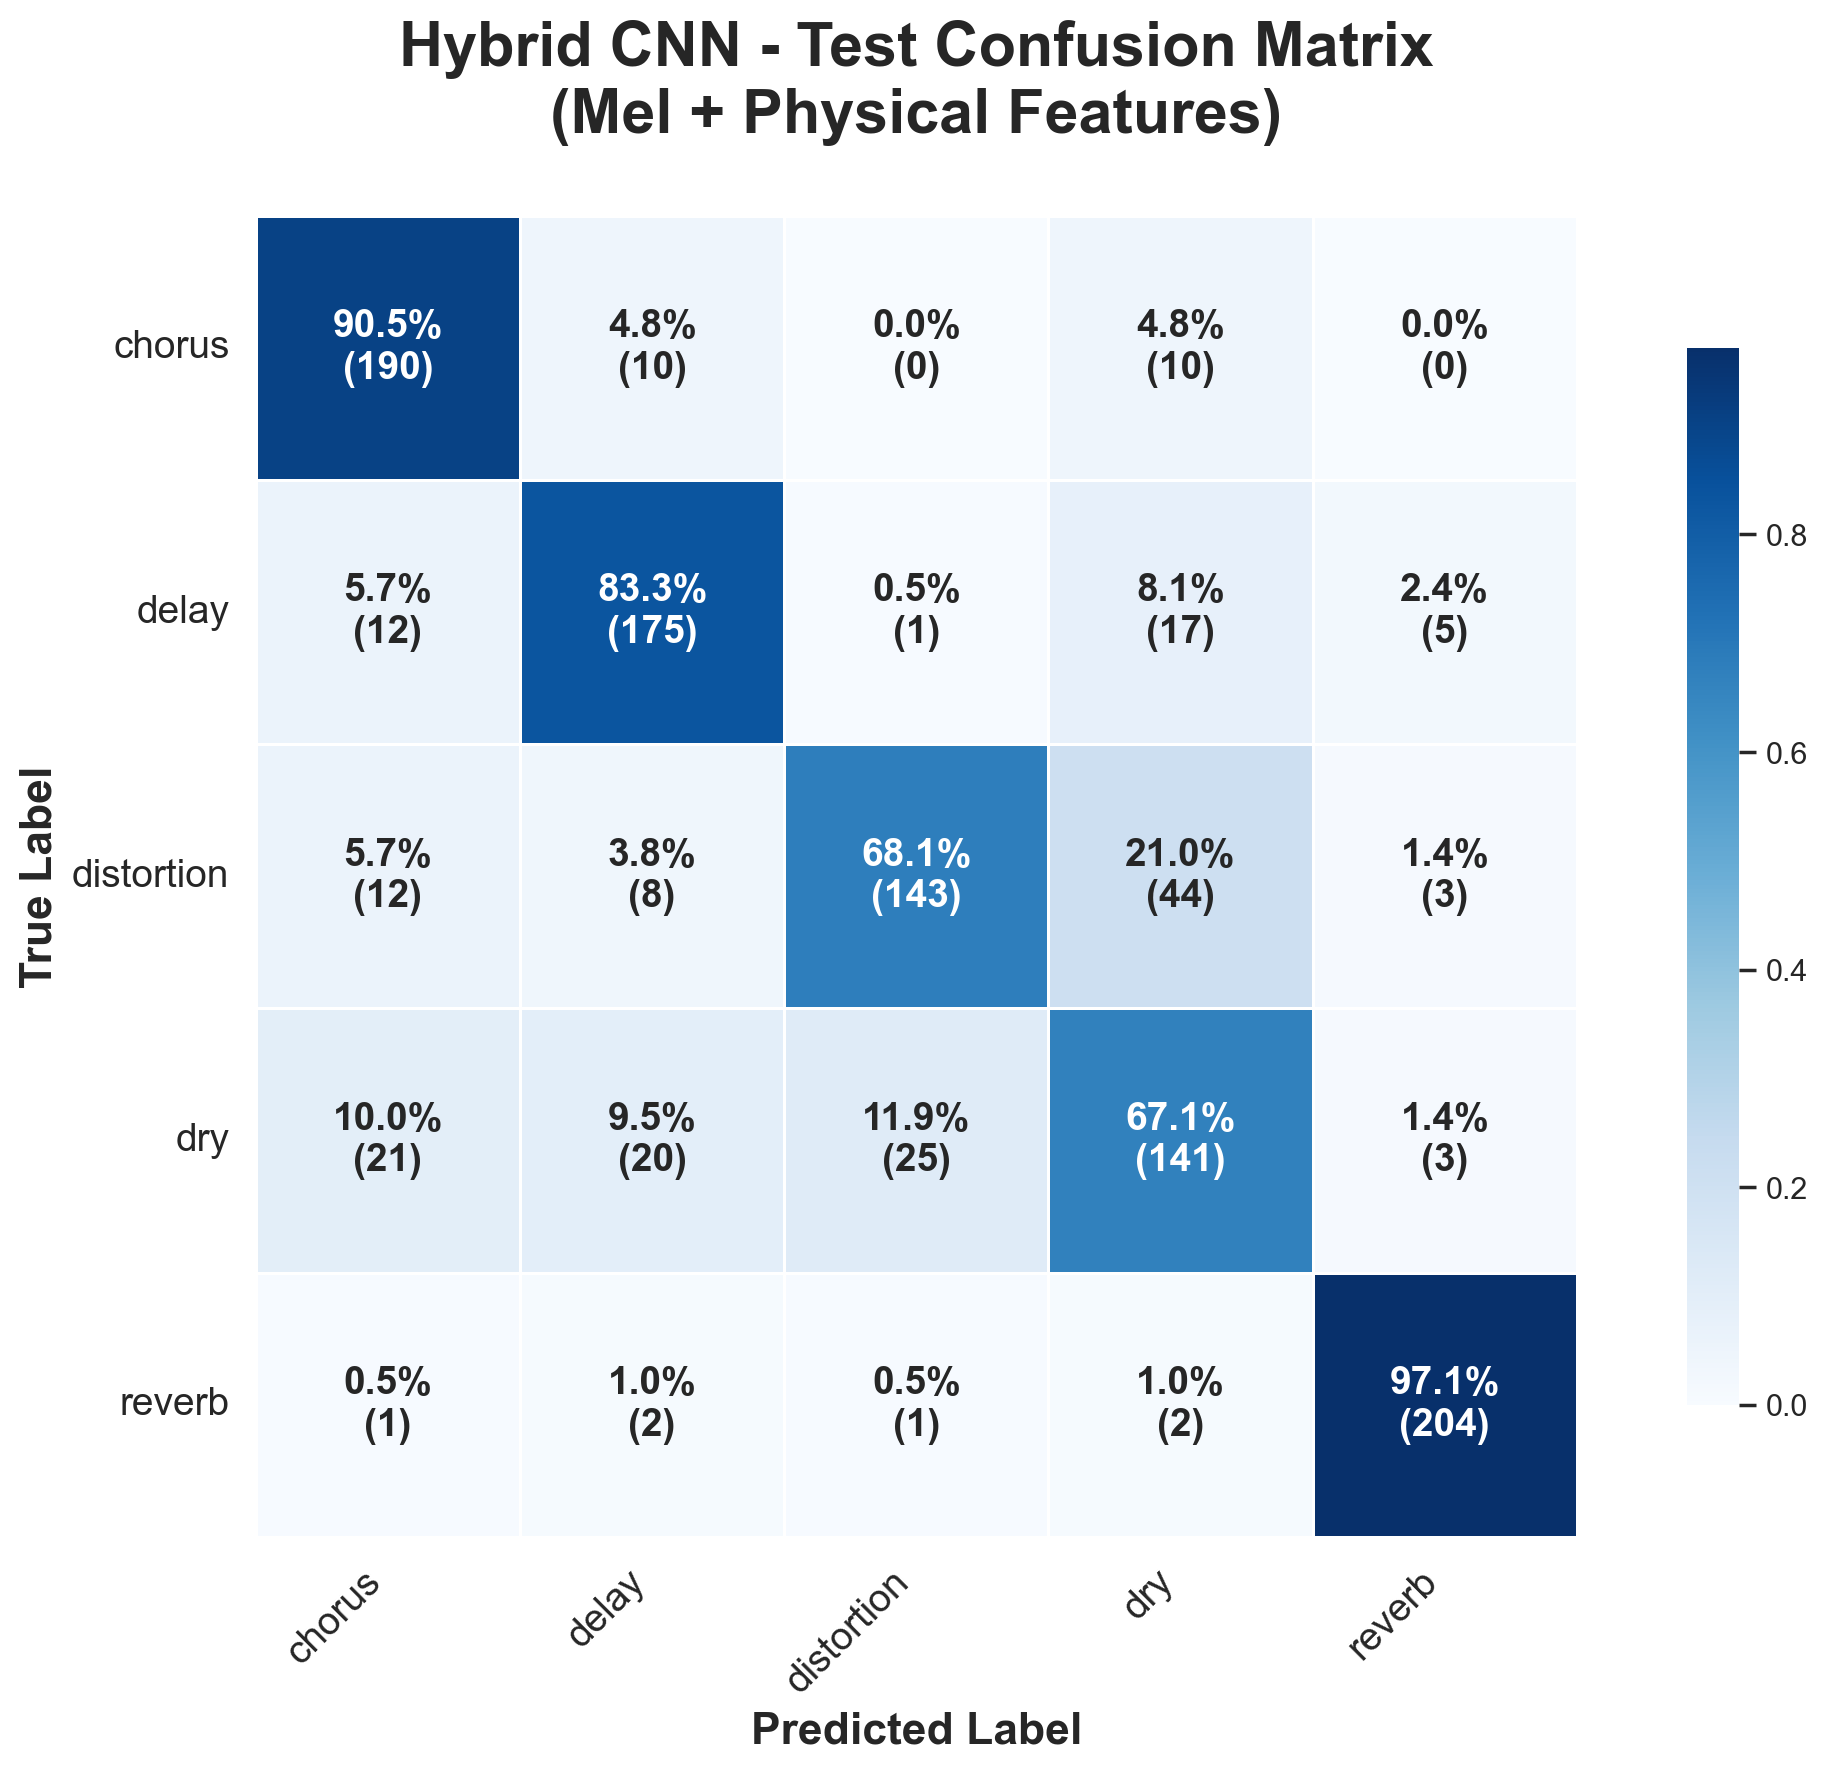

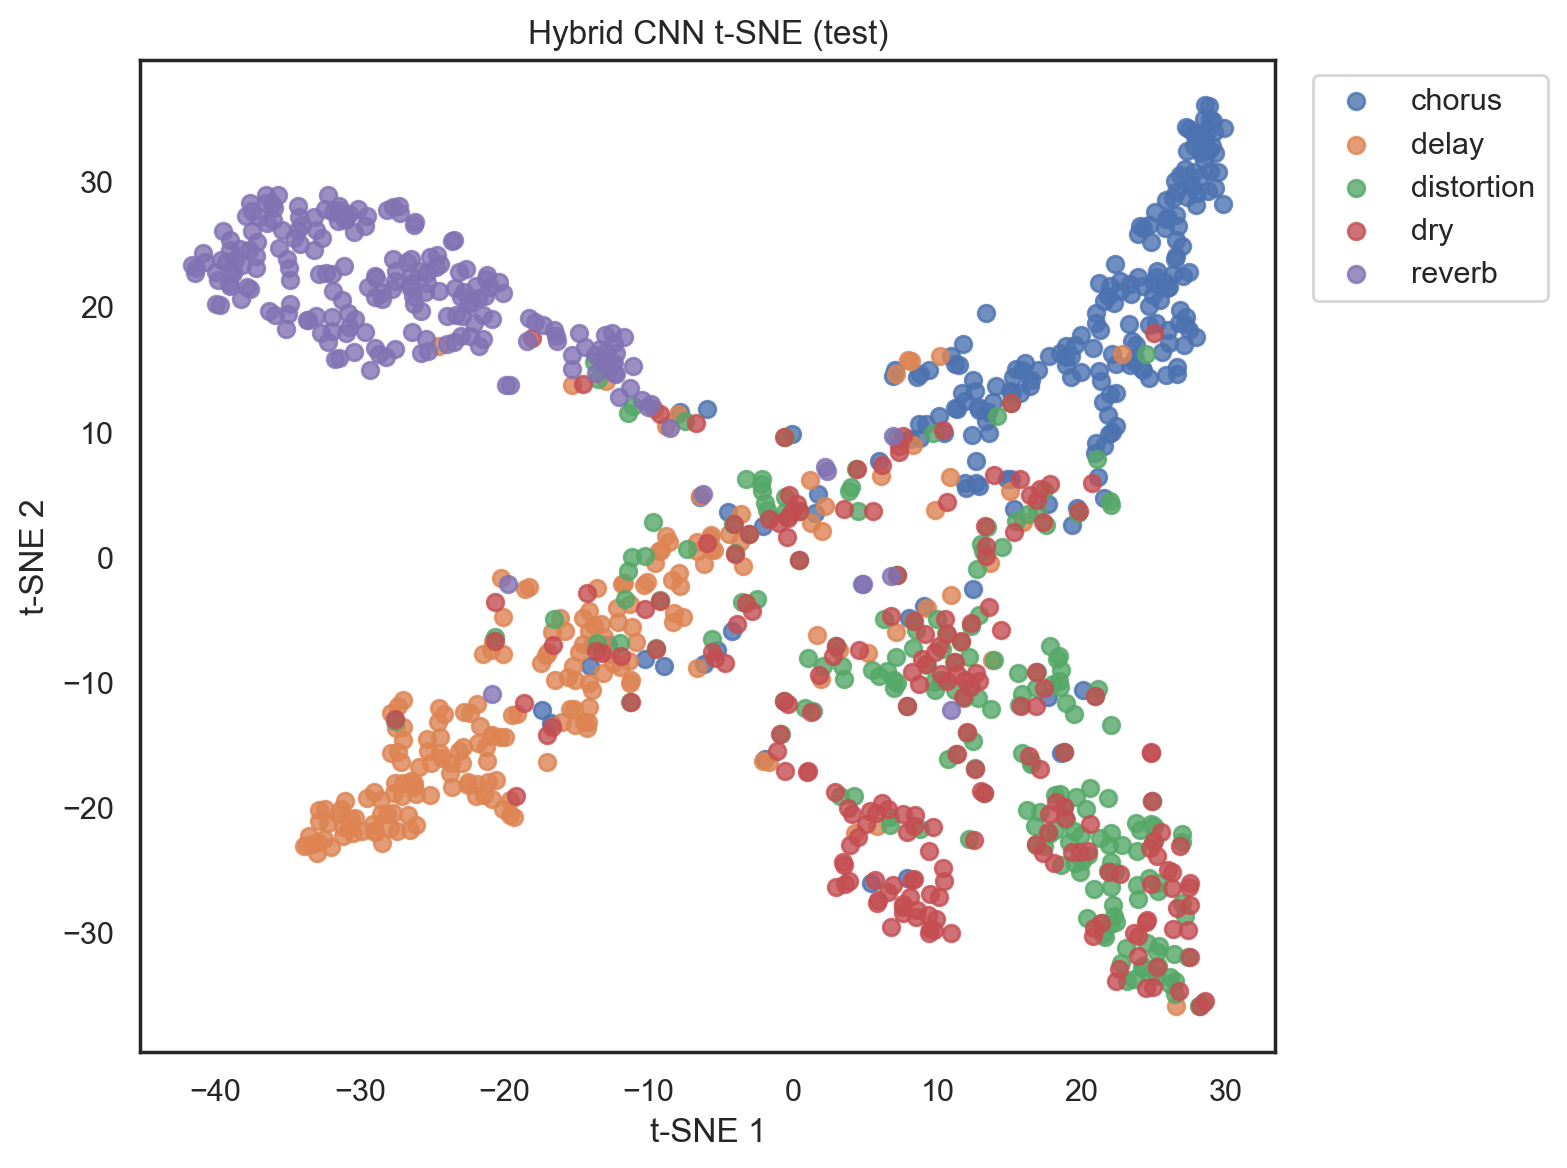

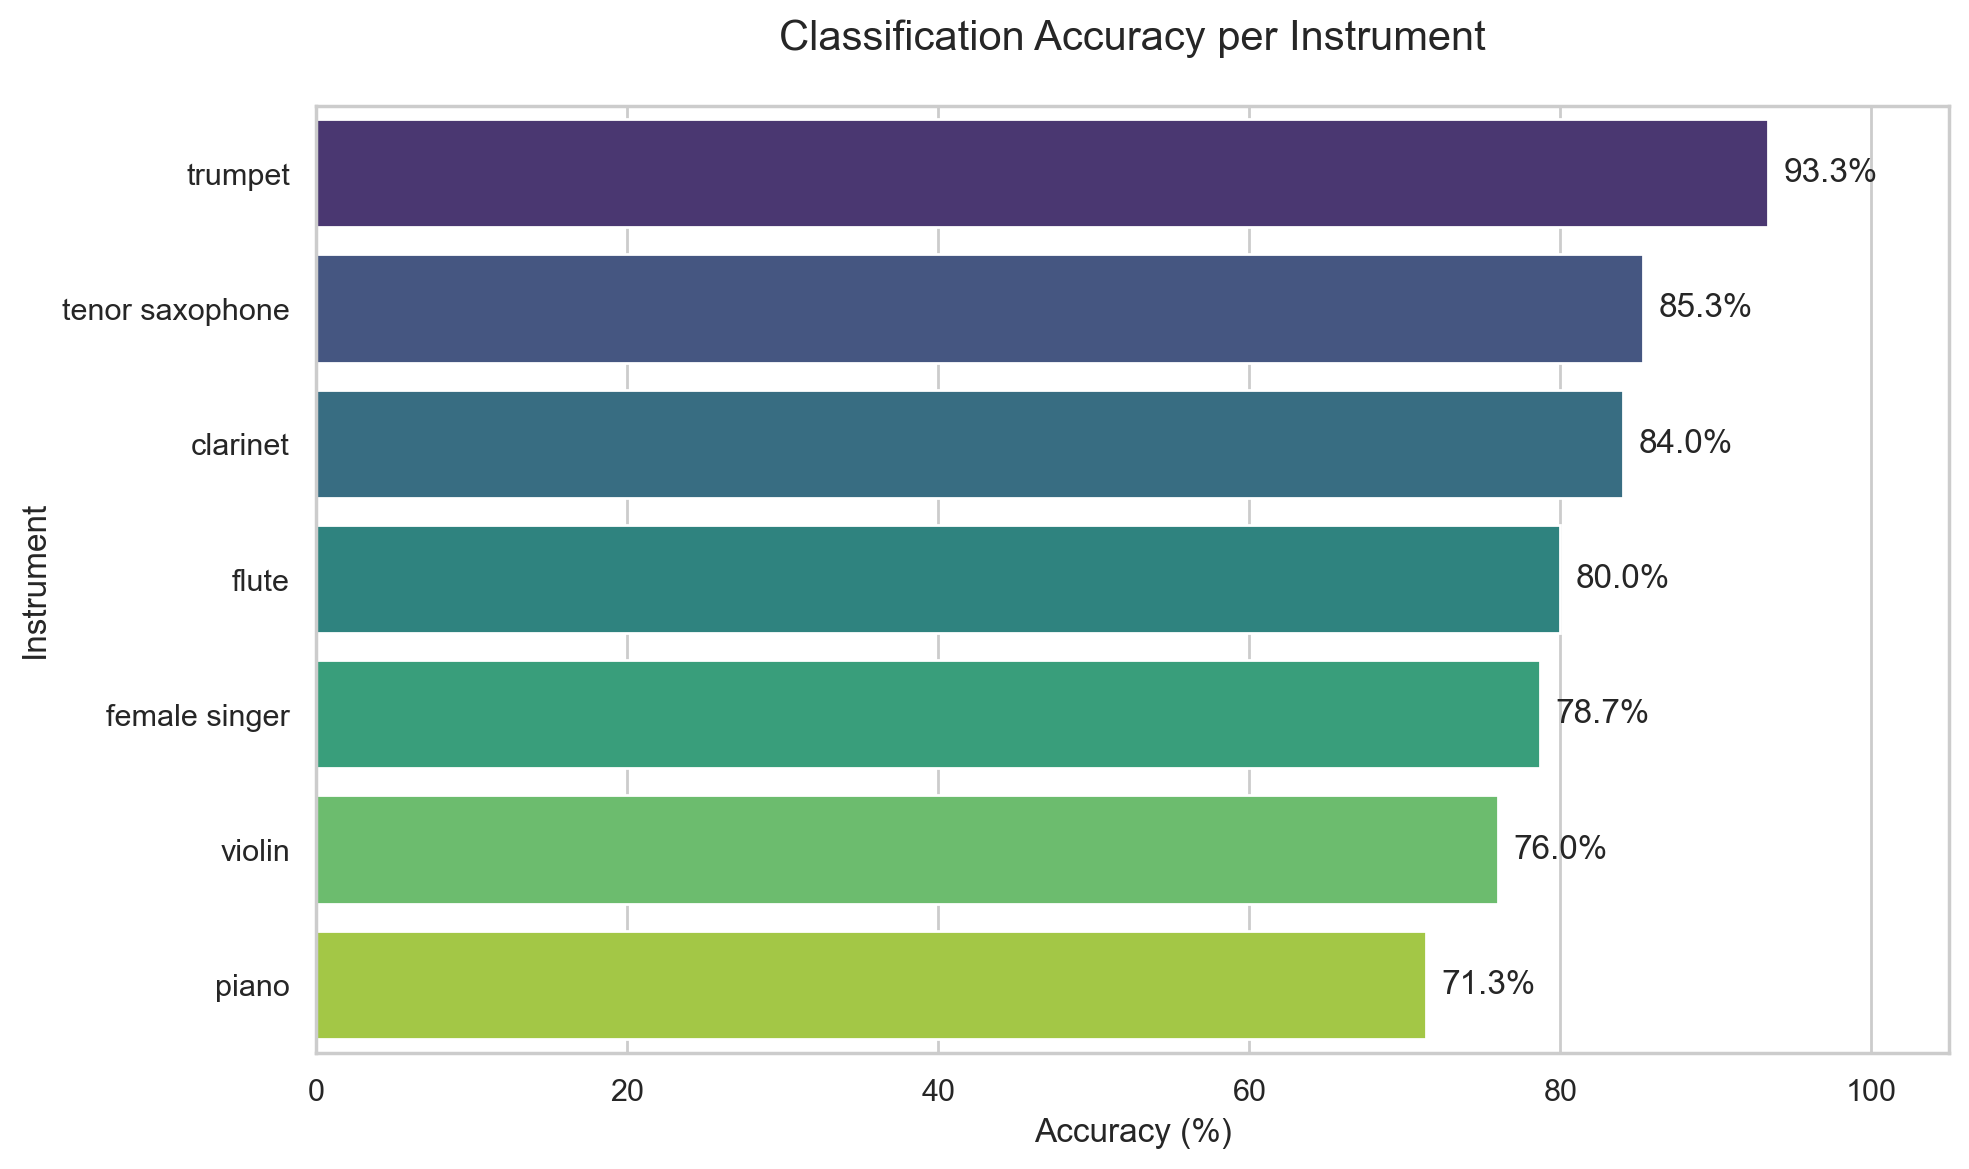

In [ ]:
# 2. Create Plots
cm_fig = plot_confusion_matrix(y_true, y_pred, class_names_final)
tsne_fig = generate_tsne_visual(model_final, test_df, dataset_kwargs, class_names_final)

instrument_fig = plot_instrument_accuracy(y_true, y_pred, instruments )

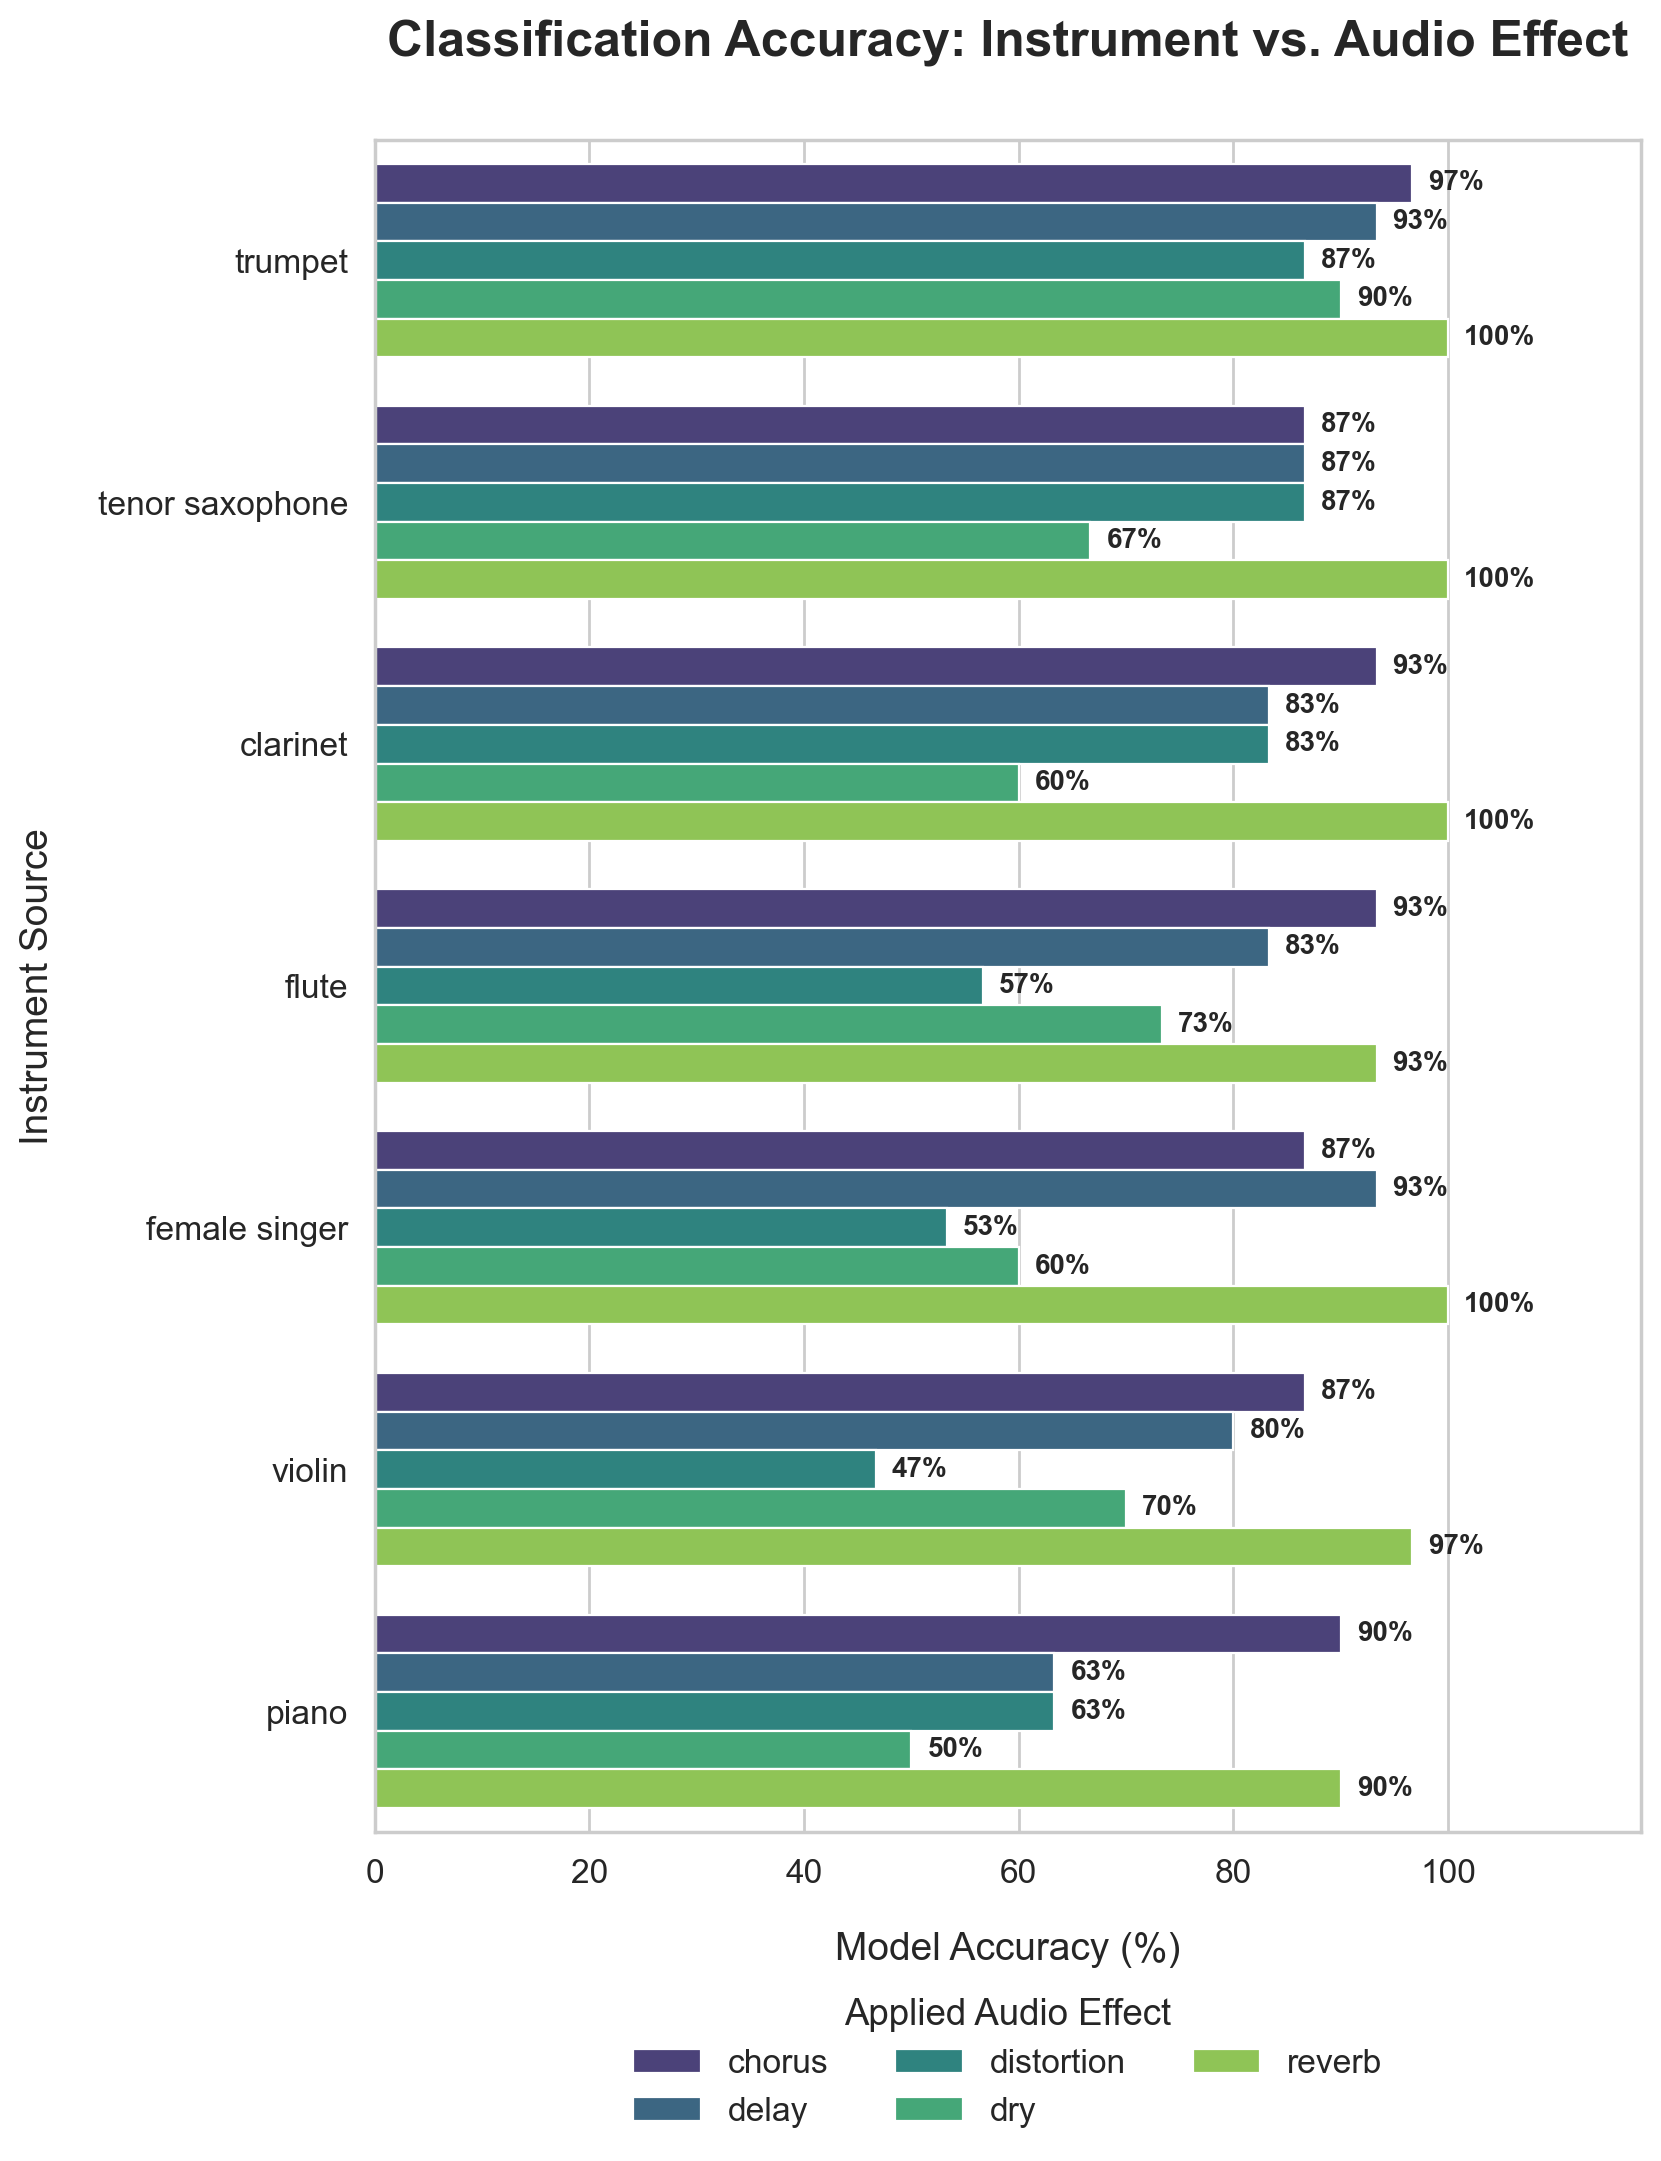

In [ ]:
intrument_clas_fig = plot_instrument_accuracy_by_effect(y_true, y_pred, instruments, class_names_final)

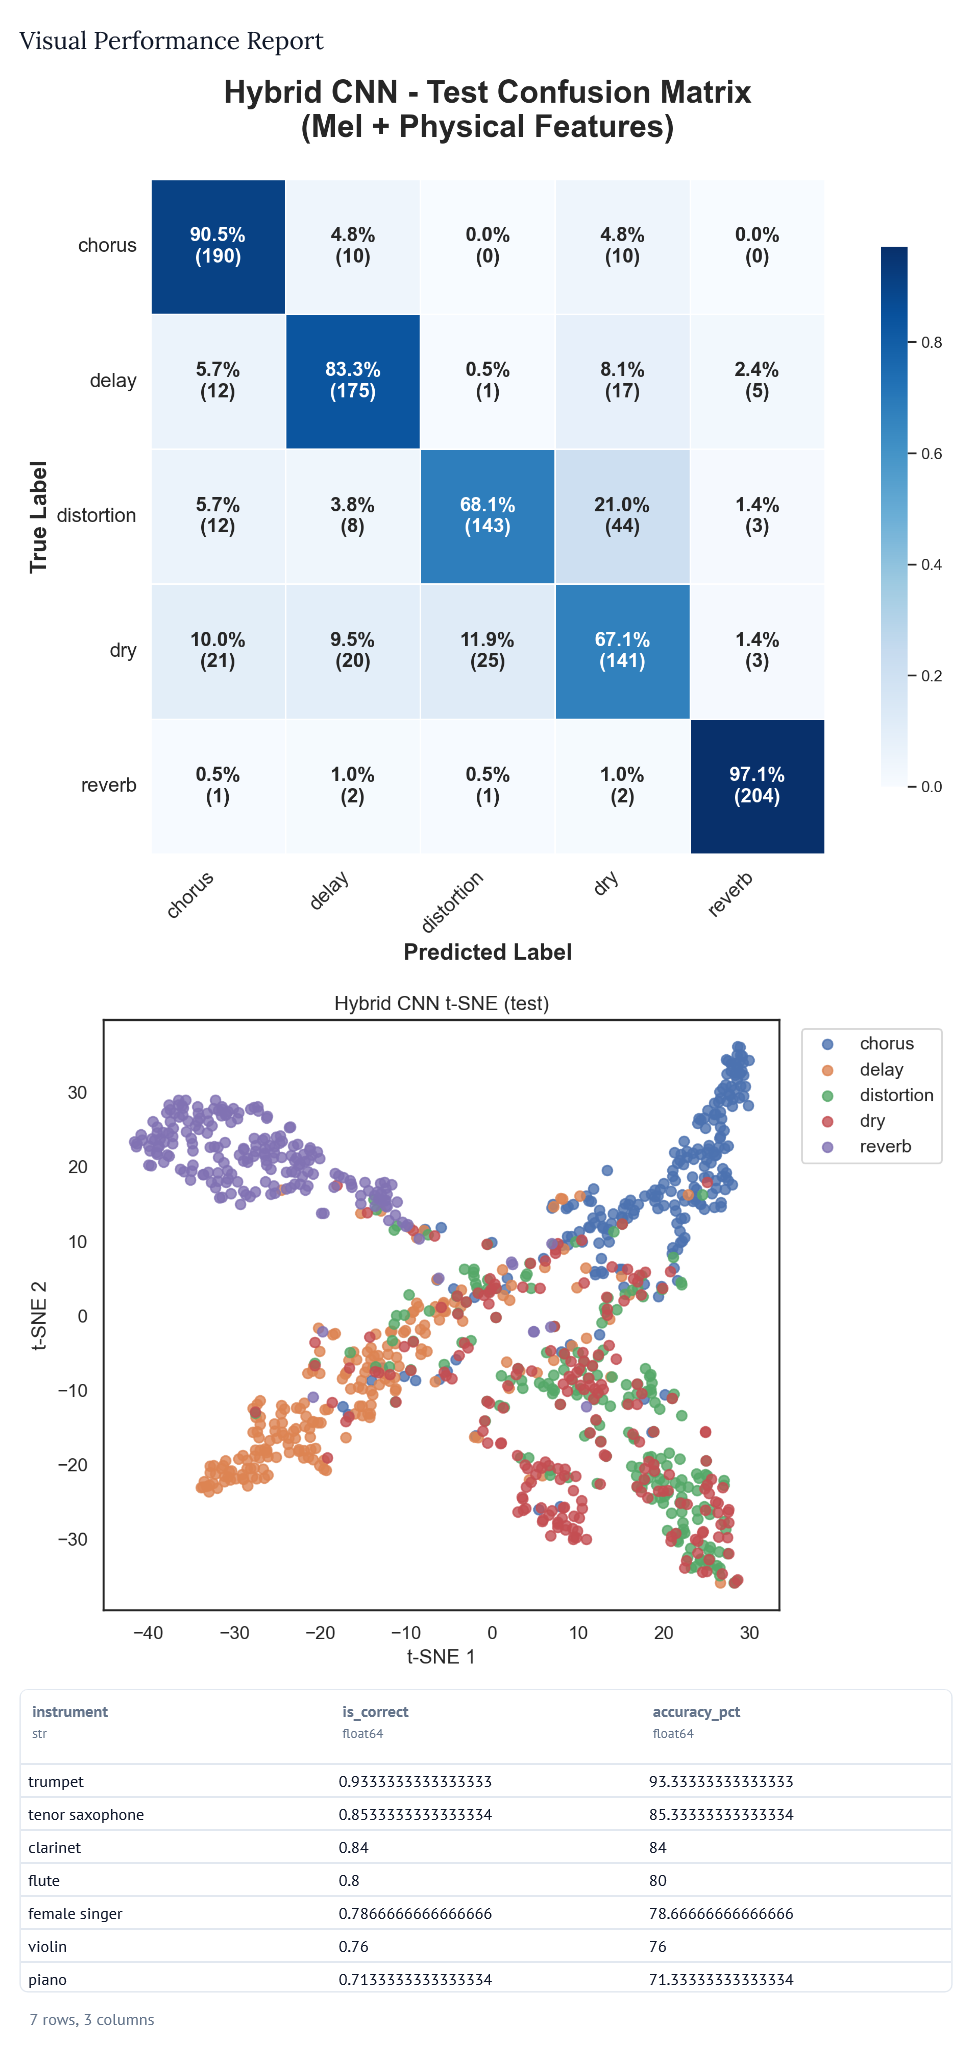

In [ ]:
mo.vstack([
    mo.md("### Visual Performance Report"),
    cm_fig,
    tsne_fig,
    instrument_fig
])

In [ ]:
MEL_CNN_CONFIG = {'sample_rate': 22050, 'fixed_duration': 3.0, 'n_mels': 128, 'n_fft': 1024, 'hop_length': 256, 'power': 2.0, 'normalize': 'per_sample', 'model_variant': 'hybrid', 'aux_feature_sets': ('rms_stats', 'spectral_flatness'), 'aux_clip_value': 5.0, 'batch_size': 32, 'num_epochs': 200, 'validation_every_n_epochs': 5, 'learning_rate': 0.001, 'weight_decay': 0.0001, 'lr_scheduler_name': 'reduce_on_plateau', 'lr_scheduler_monitor': 'val_macro_f1', 'best_model_monitor': 'val_macro_f1', 'lr_scheduler_kwargs': {'factor': 0.5, 'patience': 2, 'min_lr': 1e-06}, 'dropout': 0.3, 'cache_spectrograms': True, 'num_workers': 0, 'cache_dir': 'mel_cache_v1', 'use_disk_cache': True, 'precompute_cache': True}

In [ ]:
mel_cnn_run = train_mel_cnn(new_df_split, audio_col='new_file_path', split_col='split', label_source_col=LABEL_COL, **MEL_CNN_CONFIG)

In [ ]:
mel_cnn_model = mel_cnn_run["model"]
mel_cnn_model_variant = mel_cnn_run["model_name"]
mel_cnn_train_metrics = mel_cnn_run["metrics"]["train"]
mel_cnn_val_metrics = mel_cnn_run["metrics"]["val"]
mel_cnn_test_metrics = mel_cnn_run["metrics"]["test"]
mel_cnn_class_names = mel_cnn_run["class_names"]
mel_cnn_history_df = mel_cnn_run["history_df"]
mel_cnn_sample_shape = mel_cnn_run["sample_shape"]
mel_cnn_aux_feature_shape = mel_cnn_run["aux_feature_shape"]
mel_cnn_aux_feature_names = mel_cnn_run["aux_feature_names"]
mel_cnn_aux_diagnostics_df = mel_cnn_run["aux_diagnostics_df"]

mel_cnn_history_df

In [ ]:
mel_cnn_train_cm_df = mel_cnn_run["confusion_matrices"]["train"]
mel_cnn_val_cm_df = mel_cnn_run["confusion_matrices"]["val"]
mel_cnn_test_cm_df = mel_cnn_run["confusion_matrices"]["test"]

print("\nMel CNN train confusion matrix")
print(mel_cnn_train_cm_df)

print("\nMel CNN validation confusion matrix")
print(mel_cnn_val_cm_df)

print("\nMel CNN test confusion matrix")
print(mel_cnn_test_cm_df)

In [ ]:
# Quick t-SNE plot of the hybrid representation.
MEL_CNN_TSNE_CONFIG = {
    "split_name": "test",
    "perplexity": 30,
    "random_state": 42,
    "batch_size": 64,
    "max_samples": None,
}

mel_cnn_hybrid_tsne_df, mel_cnn_hybrid_tsne_fig, mel_cnn_hybrid_tsne_ax = plot_hybrid_tsne_for_run(
    mel_cnn_run,
    label_col="class_name",
    **MEL_CNN_TSNE_CONFIG,
)